<a href="https://colab.research.google.com/github/jhj5445/portfolio/blob/main/sectorport.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 2000~ SPX와 해당 전략 비교
! pip install fredapi
! pip install yfinance

=== 🤖 1단계: 장기 매크로 데이터 로드 및 전처리 ===
=== 📈 2단계: ETF 실전 투자 데이터 로드 ===
=== ⚙️ 3단계: AI 10% 미만 노이즈 제거 및 월별 타겟 비중 산출 ===
=== ⚙️ 3-2단계: 기관급 리밸런싱 및 수수료/Drift 계산 ===
=== 📊 4단계: 성과 지표 산출 및 시각화 (~ 현재) ===

🏆 성과 비교 (분석 기간: 2020-01-01 ~ 현재) 🏆
-----------------------------------------------------------------
전략 / 벤치마크       | CAGR (%)     | MDD (%)      | Sharpe Ratio
-----------------------------------------------------------------
🤖 AI 모델         |    11.17 % |   -36.72 % |       0.56
📈 SPY (S&P500) |    13.08 % |   -33.72 % |       0.70
-----------------------------------------------------------------
※ 누적 거래 수수료: 8.42% (정밀 차감 완료)



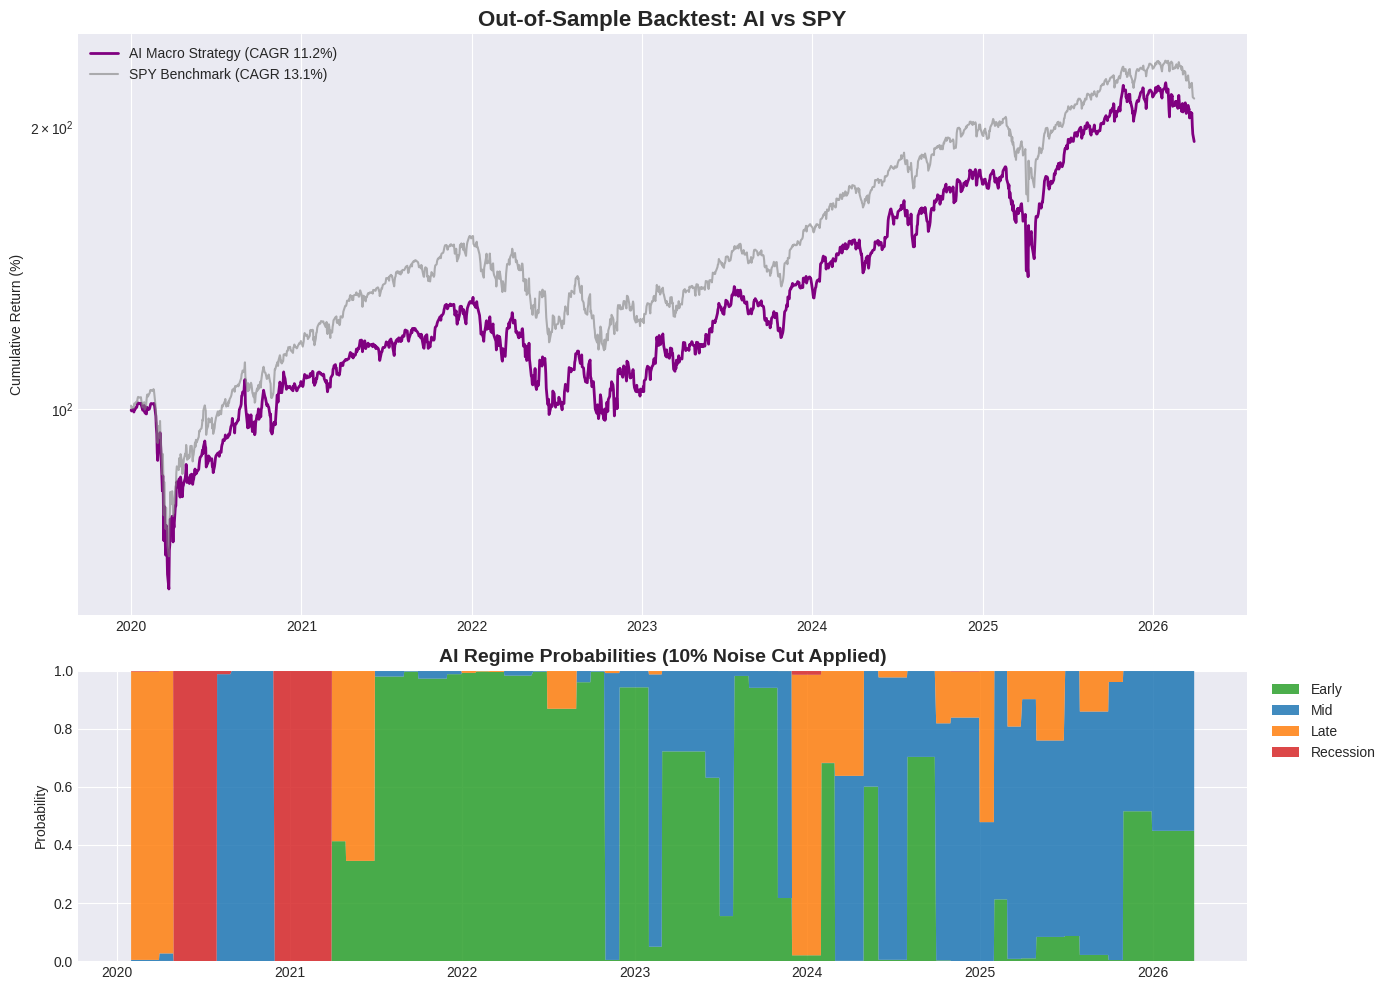

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from fredapi import Fred
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# 0. 준비: API 키 설정
# ==============================================================================
FRED_API_KEY = '2c0262037bb8a78ae5d65d9edf820cf5'
fred = Fred(api_key=FRED_API_KEY)

# ==============================================================================
# 1. 🌍 매크로 데이터 로드 및 전처리 (Expanding Window)
# ==============================================================================
print("=== 🤖 1단계: 장기 매크로 데이터 로드 및 전처리 ===")
try:
    s_baa_yield = fred.get_series('BAA')   # Baa 회사채 (1919년~)
    s_10y_yield = fred.get_series('GS10')  # 10년물 국채 (1953년~)
    s_baa = s_baa_yield - s_10y_yield      # 우리가 직접 만든 신용 스프레드

    s_indpro = fred.get_series('INDPRO')
    s_tcu = fred.get_series('TCU')
    s_payems = fred.get_series('PAYEMS')
    s_t10y2y = fred.get_series('T10Y2Y')

    # 1. 일단 다 합치고 월말 기준으로 ffill만 맞춥니다. (dropna 절대 금지!)
    df_macro = pd.concat([s_indpro, s_baa, s_tcu, s_payems, s_t10y2y], axis=1)
    df_macro.columns = ['Growth', 'Credit', 'Capacity', 'Employment', 'Policy']
    df_macro = df_macro.resample('ME').last().ffill()

    # 2. 데이터가 꽉 차 있는(과거부터 있는) 상태에서 모멘텀을 계산합니다.
    df_macro['Growth_Mom'] = df_macro['Growth'].pct_change(6)
    df_macro['Credit_Mom'] = df_macro['Credit'].diff(3)
    df_macro['Capacity_Mom'] = df_macro['Capacity'].diff(6)
    df_macro['Emp_Mom'] = df_macro['Employment'].pct_change(6)
    df_macro['Policy_Mom'] = df_macro['Policy'].diff(3)

    # 3. Z-스코어 계산도 미리 해버립니다. (각 지표별로 과거 데이터가 살아있으므로 워밍업이 빠름)
    features = ['Growth_Mom', 'Credit_Mom', 'Capacity_Mom', 'Emp_Mom', 'Policy_Mom']
    df_z = (df_macro[features] - df_macro[features].rolling(120).mean()) / df_macro[features].rolling(120).std()

    # 4. 모든 계산이 끝난 후, 모델에 넣기 직전에 깔끔하게 자릅니다.
    df_z = df_z.dropna()

except Exception as e:
    print(f"🚨 FRED 서버 오류: {e}")
    raise ValueError("FRED 서버 접속 불안정. 잠시 후 다시 실행해주세요.")

# ==============================================================================
# 2. 📈 가격 데이터 로드 (장기 백테스트를 위해 2000년부터!)
# ==============================================================================
print("=== 📈 2단계: ETF 실전 투자 데이터 로드 ===")
all_tickers = ['XLK', 'XLV', 'XLF', 'XLE', 'XLY', 'XLP', 'XLI', 'XLU', 'XLB', 'SPY','QQQ', 'VFISX']
start_date = '1999-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')

etf_data = yf.download(all_tickers, start=start_date, end=end_date, progress=False)
etf_px = etf_data['Adj Close'] if 'Adj Close' in etf_data.columns.get_level_values(0) else etf_data['Close']
etf_px = etf_px.ffill().dropna()

daily_returns = etf_px.pct_change().fillna(0.0)

# 💡 장기 테스트 시작일 조정
test_start_date = '2000-01-01'
etf_px = etf_px.loc[test_start_date:]
daily_returns = daily_returns.loc[test_start_date:]

# 💡 피델리티 오리지널 로직
cycle_playbook = {
    'Early': ['XLY', 'XLF', 'XLI', 'XLK', 'XLB'],
    'Mid': ['XLK'],
    'Late': ['XLE', 'XLP', 'XLU'],
    'Recession': ['XLY','XLP', 'XLV', 'XLU']
}

# ==============================================================================
# 3. ⚙️ 백테스트
# ==============================================================================
print("=== ⚙️ 3단계: AI 10% 미만 노이즈 제거 및 월별 타겟 비중 산출 ===")

eom_dates = etf_px.resample('ME').last().index
target_weights = pd.DataFrame(index=eom_dates, columns=etf_px.columns, data=0.0)
dynamic_probs_list = []

for date in eom_dates:
    #prob_date = date - pd.DateOffset(months=1)
    #df_train_current = df_z.loc[:prob_date]
    window_size = 120
    df_train_current = df_z[df_z.index < date].tail(window_size)
    df_train_current = df_z[df_z.index < date]
    if len(df_train_current) > 60:
        gmm = GaussianMixture(n_components=4, covariance_type='diag', random_state=42)
        gmm.fit(df_train_current)
        centroids_dynamic = gmm.means_

        # 피델리티 라벨링 로직
        growth_sorted_idx = np.argsort(centroids_dynamic[:, 0])
        idx_recession = growth_sorted_idx[0]
        idx_early = growth_sorted_idx[-1]

        rem_idx = [growth_sorted_idx[1], growth_sorted_idx[2]]
        if centroids_dynamic[rem_idx[0], 1] > centroids_dynamic[rem_idx[1], 1]:
            idx_late, idx_mid = rem_idx[0], rem_idx[1]
        else:
            idx_late, idx_mid = rem_idx[1], rem_idx[0]

        regime_map_dynamic = {
            idx_early: 'Early', idx_mid: 'Mid',
            idx_late: 'Late', idx_recession: 'Recession'
        }

        current_data = df_train_current.iloc[-1:].values
        raw_probs = gmm.predict_proba(current_data)[0]
        current_probs = {regime_map_dynamic[j]: raw_probs[j] for j in range(4)}

        prob_record = current_probs.copy()
        prob_record['Date'] = date
        dynamic_probs_list.append(prob_record)

        # 💡 [핵심] 10% 이상만 남기고 노이즈 제거
        threshold = 0.10
        filtered_probs = {regime: prob for regime, prob in current_probs.items() if prob >= threshold}

        if not filtered_probs:
            dominant_regime = max(current_probs, key=current_probs.get)
            filtered_probs = {dominant_regime: 1.0}

        # 다시 100%(1.0)로 정규화
        total_prob = sum(filtered_probs.values())
        normalized_probs = {regime: prob / total_prob for regime, prob in filtered_probs.items()}

        # 정규화된 확률로 섹터 비중 배분
        for regime, prob in normalized_probs.items():
            sectors = cycle_playbook[regime]
            weight_per_sector = prob / len(sectors)
            for s in sectors:
                target_weights.loc[date, s] += weight_per_sector
    else:
        # 데이터 부족 시 SPY 대기
        target_weights.loc[date, 'SPY'] = 1.0

df_dynamic_probs = pd.DataFrame(dynamic_probs_list).set_index('Date')

# ==============================================================================
# 3-2. ⚙️ 실전 매매 로직 적용 (월 1회 리밸런싱 + 💡휴장일 증발 버그 완벽 수정)
# ==============================================================================
print("=== ⚙️ 3-2단계: 기관급 리밸런싱 및 수수료/Drift 계산 ===")
spy_200_sma = etf_px['SPY'].rolling(window=200).mean()
spy_100_sma = etf_px['SPY'].rolling(window=100).mean()

is_bear_market = etf_px['SPY'] < spy_200_sma*0.001 # SPY가 200일선 밑으로 뚫리면 True

# 💡 [핵심 버그 수정] 달력 월말(주말)을 실제 주식시장의 '마지막 거래일'로 변환
target_months = target_weights.index.to_period('M')
last_trading_days = daily_returns.groupby(daily_returns.index.to_period('M')).apply(lambda x: x.index[-1])

target_weights.index = target_months.map(last_trading_days)
target_weights = target_weights[target_weights.index.notna()]
# 💡 [추가] 비상 브레이크 발동! (월말 기준)


bear_market_eom = is_bear_market.reindex(target_weights.index).fillna(False)
for date in target_weights.index:
    if bear_market_eom.loc[date]: # 만약 리밸런싱 당일 시장이 200일선 아래라면?
        target_weights.loc[date] = 0.0 # AI가 짠 비중 싹 다 무시하고 0으로 리셋!
        target_weights.loc[date, 'VFISX'] = 1.0 # 100% 단기채(안전마진)로 대피!

# 1. 타겟 비중을 일간 데이터 인덱스에 맞추기 (이제 주말 누락 없이 완벽 매핑됨!)
target_weights_aligned = target_weights.reindex(daily_returns.index)

# 2. 월말(EOM)에 나온 신호를 다음 거래일(월초)로 하루 미룸
rebalance_signals = target_weights_aligned.shift(1)

# 3. 리밸런싱 신호가 있는 날(월초 첫 거래일)만 True로 체크
is_rebalance_day_series = ~rebalance_signals.isna().all(axis=1)

# 4. 리밸런싱 날이면서 비중 합이 0인 날(데이터 부족 기간)만 SPY 100% 할당
zero_sum_mask = is_rebalance_day_series & (rebalance_signals.sum(axis=1) == 0)
rebalance_signals.loc[zero_sum_mask, 'SPY'] = 1.0

returns_values = daily_returns.values
target_values = rebalance_signals.fillna(0.0).values # 안전장치
is_rebalance_day = is_rebalance_day_series.values

n_days = len(daily_returns)
n_assets = len(daily_returns.columns)

port_daily_ret = np.zeros(n_days)
turnover_costs = np.zeros(n_days)

current_weights = np.zeros(n_assets)
transaction_fee_rate = 0.002 # 0.2% 수수료

for i in range(n_days):
    # 1. 리밸런싱 날 (한 달에 딱 한 번): 타겟 비중으로 교체하고 수수료 차감
    if is_rebalance_day[i]:
        target_w = target_values[i]
        turnover = np.sum(np.abs(target_w - current_weights))
        turnover_costs[i] = turnover * transaction_fee_rate
        current_weights = target_w.copy()

    # 2. 오늘의 포트폴리오 수익률 계산
    day_ret = np.sum(current_weights * returns_values[i])
    port_daily_ret[i] = day_ret - turnover_costs[i]

    # 3. 비중 자연 표류 (Weight Drift) 반영
    if (1 + day_ret) > 0:
        current_weights = current_weights * (1 + returns_values[i]) / (1 + day_ret)
    else:
        current_weights = np.zeros(n_assets)

net_daily_return = pd.Series(port_daily_ret, index=daily_returns.index)
daily_costs = pd.Series(turnover_costs, index=daily_returns.index)
# ==============================================================================
# 4. 🚀 벤치마크 비교 성과 산출 및 최종 시각화
# ==============================================================================
print("=== 📊 4단계: 성과 지표 산출 및 시각화 (~ 현재) ===")

# 💡 RSP 상장 이후인 2003년 5월 1일로 기준점 통일
valid_start = '2020-01-01'

port_ret_valid = net_daily_return.loc[valid_start:]
spy_ret_valid = daily_returns.loc[valid_start:, 'SPY']
#rsp_ret_valid = daily_returns.loc[valid_start:, 'RSP']

port_cum_valid = (1 + port_ret_valid).cumprod()
spy_cum_valid = (1 + spy_ret_valid).cumprod()
#rsp_cum_valid = (1 + rsp_ret_valid).cumprod()

def calc_metrics(daily_ret, cum_ret):
    years = len(daily_ret) / 252
    cagr = (cum_ret.iloc[-1] ** (1 / years)) - 1
    mdd = (cum_ret / cum_ret.cummax() - 1).min()
    sharpe = (daily_ret.mean() / daily_ret.std()) * np.sqrt(252)
    return cagr, mdd, sharpe

ai_cagr, ai_mdd, ai_sharpe = calc_metrics(port_ret_valid, port_cum_valid)
spy_cagr, spy_mdd, spy_sharpe = calc_metrics(spy_ret_valid, spy_cum_valid)
#rsp_cagr, rsp_mdd, rsp_sharpe = calc_metrics(rsp_ret_valid, rsp_cum_valid)

print(f"\n🏆 성과 비교 (분석 기간: {valid_start} ~ 현재) 🏆")
print("-" * 65)
print(f"{'전략 / 벤치마크':<15} | {'CAGR (%)':<12} | {'MDD (%)':<12} | {'Sharpe Ratio':<12}")
print("-" * 65)
print(f"{'🤖 AI 모델':<15} | {ai_cagr*100:>8.2f} % | {ai_mdd*100:>8.2f} % | {ai_sharpe:>10.2f}")
print(f"{'📈 SPY (S&P500)':<13} | {spy_cagr*100:>8.2f} % | {spy_mdd*100:>8.2f} % | {spy_sharpe:>10.2f}")
#print(f"{'⚖️ RSP (동일가중)':<12} | {rsp_cagr*100:>8.2f} % | {rsp_mdd*100:>8.2f} % | {rsp_sharpe:>10.2f}")
print("-" * 65)
print(f"※ 누적 거래 수수료: {daily_costs.loc[valid_start:].sum()*100:.2f}% (정밀 차감 완료)\n")

# --- 그래프 시각화 ---
plt.style.use('seaborn-v0_8-darkgrid')
fig_backtest, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]})

# 상단: 3대장 누적 수익률 비교
ax1.plot(port_cum_valid.index, port_cum_valid * 100, label=f'AI Macro Strategy (CAGR {ai_cagr*100:.1f}%)', color='purple', linewidth=2)
ax1.plot(spy_cum_valid.index, spy_cum_valid * 100, label=f'SPY Benchmark (CAGR {spy_cagr*100:.1f}%)', color='gray', alpha=0.6)
#ax1.plot(rsp_cum_valid.index, rsp_cum_valid * 100, label=f'RSP Equal-Weight (CAGR {rsp_cagr*100:.1f}%)', color='royalblue', alpha=0.7, linestyle='--')
ax1.set_title('Out-of-Sample Backtest: AI vs SPY', fontsize=16, fontweight='bold')
ax1.set_ylabel('Cumulative Return (%)')
ax1.set_yscale('log')
ax1.legend(loc='upper left')

# 하단: 국면 확률 (10% 노이즈 컷 이후)
probs_aligned = df_dynamic_probs.reindex(port_cum_valid.index).ffill().dropna()
ax2.stackplot(probs_aligned.index,
              probs_aligned['Early'], probs_aligned['Mid'],
              probs_aligned['Late'], probs_aligned['Recession'],
              labels=['Early', 'Mid', 'Late', 'Recession'],
              colors=['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'], alpha=0.85)
ax2.set_title('AI Regime Probabilities (10% Noise Cut Applied)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Probability')
ax2.set_ylim(0, 1)
ax2.legend(loc='upper left', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.show()

In [ ]:
df_z

,Growth_Mom,Credit_Mom,Capacity_Mom,Emp_Mom,Policy_Mom
1991-03-31,-2.212606,-1.201350,-1.712062,-3.268438,0.285177
1991-04-30,-1.947853,-1.420604,-1.186795,-3.140255,0.740896
1991-05-31,-1.677510,-0.910484,0.286073,-3.027848,1.286634
1991-06-30,-1.485213,-0.830087,1.454016,-2.744557,0.950637
1991-07-31,-1.299067,-0.582769,1.415698,-2.549420,0.468564
...,...,...,...,...,...
2025-11-30,0.228589,0.097753,-0.652376,-0.641911,-0.249742
2025-12-31,-0.001650,0.383375,-0.390743,-0.779472,0.469545
2026-01-31,0.261584,-0.217047,0.766876,-0.838520,0.710347
2026-02-28,-0.032820,0.205702,0.763728,-0.991639,0.177527


=== 🤖 1단계: 장기 매크로 데이터 로드 및 전처리 ===
=== 📈 2단계: ETF 실전 투자 데이터 로드 ===
=== ⚙️ 3단계: AI 10% 미만 노이즈 제거 및 월별 타겟 비중 산출 ===
=== ⚙️ 3-2단계: 기관급 리밸런싱 및 수수료/Drift 계산 ===
=== 📊 4단계: 성과 지표 산출 및 시각화 (~ 현재) ===

🏆 성과 비교 (분석 기간: 2000-01-01 ~ 현재) 🏆
-----------------------------------------------------------------
전략 / 벤치마크       | CAGR (%)     | MDD (%)      | Sharpe Ratio
-----------------------------------------------------------------
🤖 AI 모델         |     9.50 % |   -50.44 % |       0.54
📈 SPY (S&P500) |     7.64 % |   -55.19 % |       0.48
-----------------------------------------------------------------
※ 누적 거래 수수료: 23.74% (정밀 차감 완료)



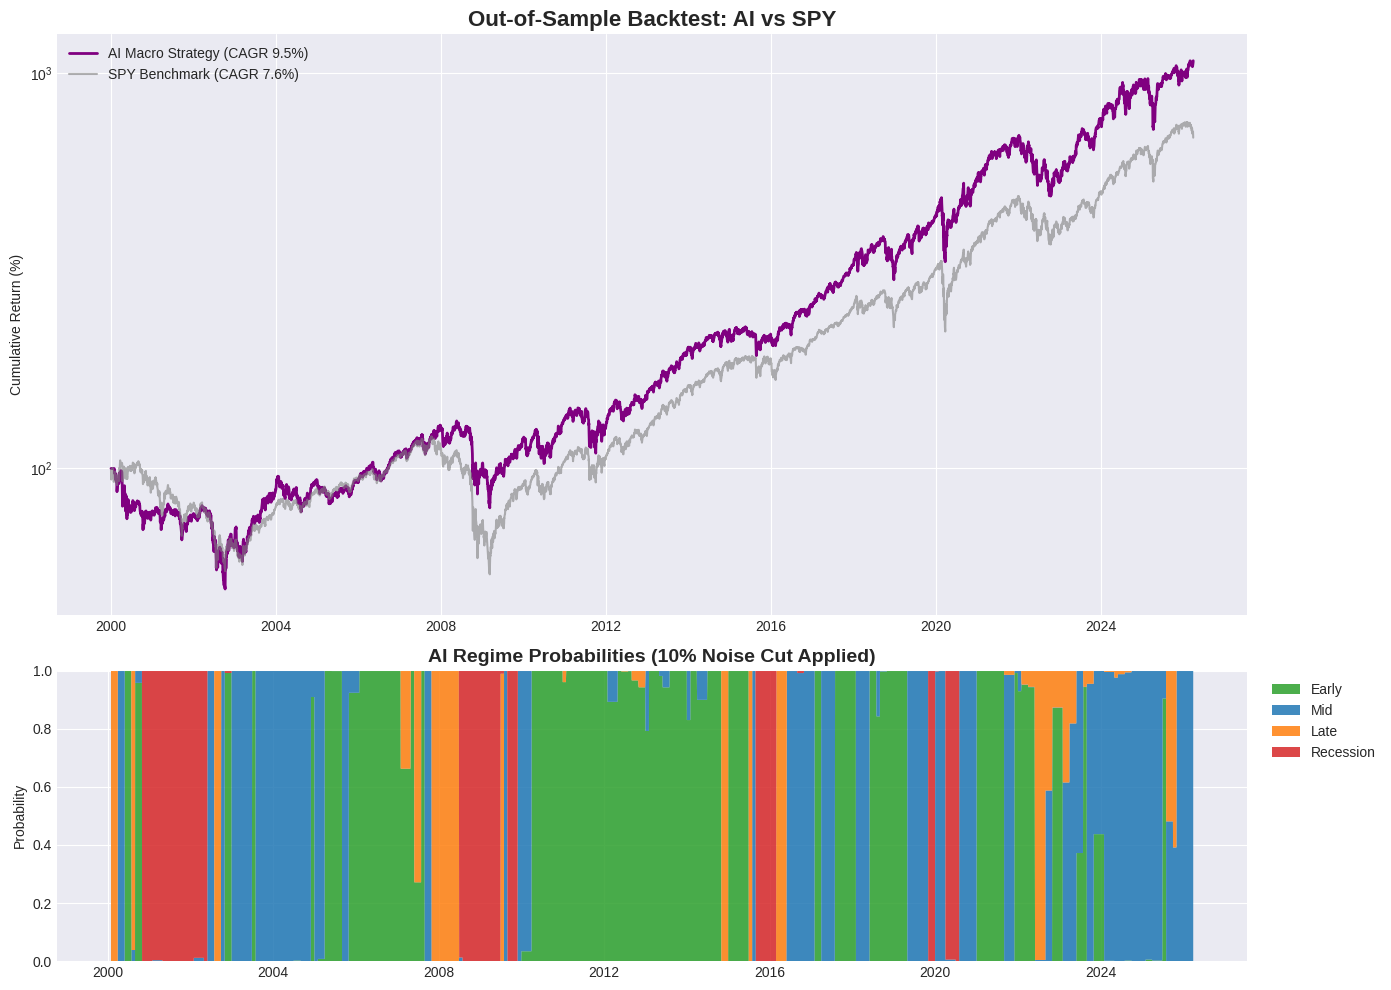

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from fredapi import Fred
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# 0. 준비: API 키 설정
# ==============================================================================
FRED_API_KEY = '2c0262037bb8a78ae5d65d9edf820cf5'
fred = Fred(api_key=FRED_API_KEY)

# ==============================================================================
# 1. 🌍 매크로 데이터 로드 및 전처리 (Expanding Window)
# ==============================================================================
print("=== 🤖 1단계: 장기 매크로 데이터 로드 및 전처리 ===")
try:
    s_baa_yield = fred.get_series('BAA')   # Baa 회사채 (1919년~)
    s_10y_yield = fred.get_series('GS10')  # 10년물 국채 (1953년~)
    s_baa = s_baa_yield - s_10y_yield      # 우리가 직접 만든 신용 스프레드

    s_indpro = fred.get_series('INDPRO')
    s_tcu = fred.get_series('TCU')
    s_payems = fred.get_series('PAYEMS')
    s_t10y2y = fred.get_series('T10Y2Y')

    # 1. 일단 다 합치고 월말 기준으로 ffill만 맞춥니다. (dropna 절대 금지!)
    df_macro = pd.concat([s_indpro, s_baa, s_tcu, s_payems, s_t10y2y], axis=1)
    df_macro.columns = ['Growth', 'Credit', 'Capacity', 'Employment', 'Policy']
    df_macro = df_macro.resample('ME').last().ffill()

    # 2. 데이터가 꽉 차 있는(과거부터 있는) 상태에서 모멘텀을 계산합니다.
    df_macro['Growth_Mom'] = df_macro['Growth'].pct_change(6)
    df_macro['Credit_Mom'] = df_macro['Credit'].diff(3)
    df_macro['Capacity_Mom'] = df_macro['Capacity'].diff(6)
    df_macro['Emp_Mom'] = df_macro['Employment'].pct_change(6)
    df_macro['Policy_Mom'] = df_macro['Policy'].diff(3)

    # 3. Z-스코어 계산도 미리 해버립니다. (각 지표별로 과거 데이터가 살아있으므로 워밍업이 빠름)
    features = ['Growth_Mom', 'Credit_Mom', 'Capacity_Mom', 'Emp_Mom', 'Policy_Mom']
    df_z = (df_macro[features] - df_macro[features].rolling(60).mean()) / df_macro[features].rolling(60).std()

    # 4. 모든 계산이 끝난 후, 모델에 넣기 직전에 깔끔하게 자릅니다.
    df_z = df_z.dropna()

except Exception as e:
    print(f"🚨 FRED 서버 오류: {e}")
    raise ValueError("FRED 서버 접속 불안정. 잠시 후 다시 실행해주세요.")

# ==============================================================================
# 2. 📈 가격 데이터 로드 (장기 백테스트를 위해 2000년부터!)
# ==============================================================================
print("=== 📈 2단계: ETF 실전 투자 데이터 로드 ===")
all_tickers = ['XLK', 'XLV', 'XLF', 'XLE', 'XLY', 'XLP', 'XLI', 'XLU', 'XLB', 'SPY','QQQ']
start_date = '1999-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')

etf_data = yf.download(all_tickers, start=start_date, end=end_date, progress=False)
etf_px = etf_data['Adj Close'] if 'Adj Close' in etf_data.columns.get_level_values(0) else etf_data['Close']
etf_px = etf_px.ffill().dropna()

daily_returns = etf_px.pct_change().fillna(0.0)

# 💡 장기 테스트 시작일 조정
test_start_date = '2000-01-01'
etf_px = etf_px.loc[test_start_date:]
daily_returns = daily_returns.loc[test_start_date:]

# 💡 피델리티 오리지널 로직
cycle_playbook = {
    'Early': ['XLY', 'XLF', 'XLI', 'XLK', 'XLB'],
    'Mid': ['XLK'],
    'Late': ['XLE', 'XLP', 'XLU'],
    'Recession': ['XLY','XLP', 'XLV', 'XLU']
}

# ==============================================================================
# 3. ⚙️ 백테스트
# ==============================================================================
print("=== ⚙️ 3단계: AI 10% 미만 노이즈 제거 및 월별 타겟 비중 산출 ===")

eom_dates = etf_px.resample('ME').last().index
target_weights = pd.DataFrame(index=eom_dates, columns=etf_px.columns, data=0.0)
dynamic_probs_list = []

for date in eom_dates:
    prob_date = date - pd.DateOffset(months=1)
    window_size = 120
    df_train_current = df_z.loc[:prob_date].tail(window_size)

    if len(df_train_current) > 60:
        gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
        gmm.fit(df_train_current)
        centroids_dynamic = gmm.means_

        # 피델리티 라벨링 로직
        growth_sorted_idx = np.argsort(centroids_dynamic[:, 0])
        idx_recession = growth_sorted_idx[0]
        idx_early = growth_sorted_idx[-1]

        rem_idx = [growth_sorted_idx[1], growth_sorted_idx[2]]
        if centroids_dynamic[rem_idx[0], 1] > centroids_dynamic[rem_idx[1], 1]:
            idx_late, idx_mid = rem_idx[0], rem_idx[1]
        else:
            idx_late, idx_mid = rem_idx[1], rem_idx[0]

        regime_map_dynamic = {
            idx_early: 'Early', idx_mid: 'Mid',
            idx_late: 'Late', idx_recession: 'Recession'
        }

        current_data = df_train_current.iloc[-1:].values
        raw_probs = gmm.predict_proba(current_data)[0]
        current_probs = {regime_map_dynamic[j]: raw_probs[j] for j in range(4)}

        prob_record = current_probs.copy()
        prob_record['Date'] = date
        dynamic_probs_list.append(prob_record)

        # 💡 [핵심] 10% 이상만 남기고 노이즈 제거
        threshold = 0.10
        filtered_probs = {regime: prob for regime, prob in current_probs.items() if prob >= threshold}

        if not filtered_probs:
            dominant_regime = max(current_probs, key=current_probs.get)
            filtered_probs = {dominant_regime: 1.0}

        # 다시 100%(1.0)로 정규화
        total_prob = sum(filtered_probs.values())
        normalized_probs = {regime: prob / total_prob for regime, prob in filtered_probs.items()}

        # 정규화된 확률로 섹터 비중 배분
        for regime, prob in normalized_probs.items():
            sectors = cycle_playbook[regime]
            weight_per_sector = prob / len(sectors)
            for s in sectors:
                target_weights.loc[date, s] += weight_per_sector
    else:
        # 데이터 부족 시 SPY 대기
        target_weights.loc[date, 'SPY'] = 1.0

df_dynamic_probs = pd.DataFrame(dynamic_probs_list).set_index('Date')

# ==============================================================================
# 3-2. ⚙️ 실전 매매 로직 적용 (월 1회 리밸런싱 + 💡휴장일 증발 버그 완벽 수정)
# ==============================================================================
print("=== ⚙️ 3-2단계: 기관급 리밸런싱 및 수수료/Drift 계산 ===")

# 💡 [핵심 버그 수정] 달력 월말(주말)을 실제 주식시장의 '마지막 거래일'로 변환
target_months = target_weights.index.to_period('M')
last_trading_days = daily_returns.groupby(daily_returns.index.to_period('M')).apply(lambda x: x.index[-1])

target_weights.index = target_months.map(last_trading_days)
target_weights = target_weights[target_weights.index.notna()]

# 1. 타겟 비중을 일간 데이터 인덱스에 맞추기 (이제 주말 누락 없이 완벽 매핑됨!)
target_weights_aligned = target_weights.reindex(daily_returns.index)

# 2. 월말(EOM)에 나온 신호를 다음 거래일(월초)로 하루 미룸
rebalance_signals = target_weights_aligned.shift(1)

# 3. 리밸런싱 신호가 있는 날(월초 첫 거래일)만 True로 체크
is_rebalance_day_series = ~rebalance_signals.isna().all(axis=1)

# 4. 리밸런싱 날이면서 비중 합이 0인 날(데이터 부족 기간)만 SPY 100% 할당
zero_sum_mask = is_rebalance_day_series & (rebalance_signals.sum(axis=1) == 0)
rebalance_signals.loc[zero_sum_mask, 'SPY'] = 1.0

returns_values = daily_returns.values
target_values = rebalance_signals.fillna(0.0).values # 안전장치
is_rebalance_day = is_rebalance_day_series.values

n_days = len(daily_returns)
n_assets = len(daily_returns.columns)

port_daily_ret = np.zeros(n_days)
turnover_costs = np.zeros(n_days)

current_weights = np.zeros(n_assets)
transaction_fee_rate = 0.002 # 0.2% 수수료

for i in range(n_days):
    # 1. 리밸런싱 날 (한 달에 딱 한 번): 타겟 비중으로 교체하고 수수료 차감
    if is_rebalance_day[i]:
        target_w = target_values[i]
        turnover = np.sum(np.abs(target_w - current_weights))
        turnover_costs[i] = turnover * transaction_fee_rate
        current_weights = target_w.copy()

    # 2. 오늘의 포트폴리오 수익률 계산
    day_ret = np.sum(current_weights * returns_values[i])
    port_daily_ret[i] = day_ret - turnover_costs[i]

    # 3. 비중 자연 표류 (Weight Drift) 반영
    if (1 + day_ret) > 0:
        current_weights = current_weights * (1 + returns_values[i]) / (1 + day_ret)
    else:
        current_weights = np.zeros(n_assets)

net_daily_return = pd.Series(port_daily_ret, index=daily_returns.index)
daily_costs = pd.Series(turnover_costs, index=daily_returns.index)
# ==============================================================================
# 4. 🚀 벤치마크 비교 성과 산출 및 최종 시각화
# ==============================================================================
print("=== 📊 4단계: 성과 지표 산출 및 시각화 (~ 현재) ===")

# 💡 RSP 상장 이후인 2003년 5월 1일로 기준점 통일
valid_start = '2000-01-01'

port_ret_valid = net_daily_return.loc[valid_start:]
spy_ret_valid = daily_returns.loc[valid_start:, 'SPY']
#rsp_ret_valid = daily_returns.loc[valid_start:, 'RSP']

port_cum_valid = (1 + port_ret_valid).cumprod()
spy_cum_valid = (1 + spy_ret_valid).cumprod()
#rsp_cum_valid = (1 + rsp_ret_valid).cumprod()

def calc_metrics(daily_ret, cum_ret):
    years = len(daily_ret) / 252
    cagr = (cum_ret.iloc[-1] ** (1 / years)) - 1
    mdd = (cum_ret / cum_ret.cummax() - 1).min()
    sharpe = (daily_ret.mean() / daily_ret.std()) * np.sqrt(252)
    return cagr, mdd, sharpe

ai_cagr, ai_mdd, ai_sharpe = calc_metrics(port_ret_valid, port_cum_valid)
spy_cagr, spy_mdd, spy_sharpe = calc_metrics(spy_ret_valid, spy_cum_valid)
#rsp_cagr, rsp_mdd, rsp_sharpe = calc_metrics(rsp_ret_valid, rsp_cum_valid)

print(f"\n🏆 성과 비교 (분석 기간: {valid_start} ~ 현재) 🏆")
print("-" * 65)
print(f"{'전략 / 벤치마크':<15} | {'CAGR (%)':<12} | {'MDD (%)':<12} | {'Sharpe Ratio':<12}")
print("-" * 65)
print(f"{'🤖 AI 모델':<15} | {ai_cagr*100:>8.2f} % | {ai_mdd*100:>8.2f} % | {ai_sharpe:>10.2f}")
print(f"{'📈 SPY (S&P500)':<13} | {spy_cagr*100:>8.2f} % | {spy_mdd*100:>8.2f} % | {spy_sharpe:>10.2f}")
#print(f"{'⚖️ RSP (동일가중)':<12} | {rsp_cagr*100:>8.2f} % | {rsp_mdd*100:>8.2f} % | {rsp_sharpe:>10.2f}")
print("-" * 65)
print(f"※ 누적 거래 수수료: {daily_costs.loc[valid_start:].sum()*100:.2f}% (정밀 차감 완료)\n")

# --- 그래프 시각화 ---
plt.style.use('seaborn-v0_8-darkgrid')
fig_backtest, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]})

# 상단: 3대장 누적 수익률 비교
ax1.plot(port_cum_valid.index, port_cum_valid * 100, label=f'AI Macro Strategy (CAGR {ai_cagr*100:.1f}%)', color='purple', linewidth=2)
ax1.plot(spy_cum_valid.index, spy_cum_valid * 100, label=f'SPY Benchmark (CAGR {spy_cagr*100:.1f}%)', color='gray', alpha=0.6)
#ax1.plot(rsp_cum_valid.index, rsp_cum_valid * 100, label=f'RSP Equal-Weight (CAGR {rsp_cagr*100:.1f}%)', color='royalblue', alpha=0.7, linestyle='--')
ax1.set_title('Out-of-Sample Backtest: AI vs SPY', fontsize=16, fontweight='bold')
ax1.set_ylabel('Cumulative Return (%)')
#ax1.set_yscale('log')
ax1.legend(loc='upper left')

# 하단: 국면 확률 (10% 노이즈 컷 이후)
probs_aligned = df_dynamic_probs.reindex(port_cum_valid.index).ffill().dropna()
ax2.stackplot(probs_aligned.index,
              probs_aligned['Early'], probs_aligned['Mid'],
              probs_aligned['Late'], probs_aligned['Recession'],
              labels=['Early', 'Mid', 'Late', 'Recession'],
              colors=['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'], alpha=0.85)
ax2.set_title('AI Regime Probabilities (10% Noise Cut Applied)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Probability')
ax2.set_ylim(0, 1)
ax2.legend(loc='upper left', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.show()

=== 🤖 1단계: 장기 매크로 데이터 로드 및 전처리 ===
=== 📈 2단계: ETF 실전 투자 데이터 로드 ===
=== ⚙️ 3단계: AI 10% 미만 노이즈 제거 및 월별 타겟 비중 산출 ===
=== ⚙️ 3-2단계: 기관급 리밸런싱 및 200일선 비상 브레이크 (Absolute Momentum) 적용 ===
=== 📊 4단계: 성과 지표 산출 및 시각화 (~ 현재) ===

🏆 성과 비교 (분석 기간: 2000-01-01 ~ 현재) 🏆
-----------------------------------------------------------------
전략 / 벤치마크       | CAGR (%)     | MDD (%)      | Sharpe Ratio
-----------------------------------------------------------------
🤖 AI 모델 (+비상브레이크) |     8.74 % |   -29.48 % |       0.64
📈 SPY (S&P500) |     7.62 % |   -55.19 % |       0.48
-----------------------------------------------------------------
※ 누적 거래 수수료: 45.81% (정밀 차감 완료)



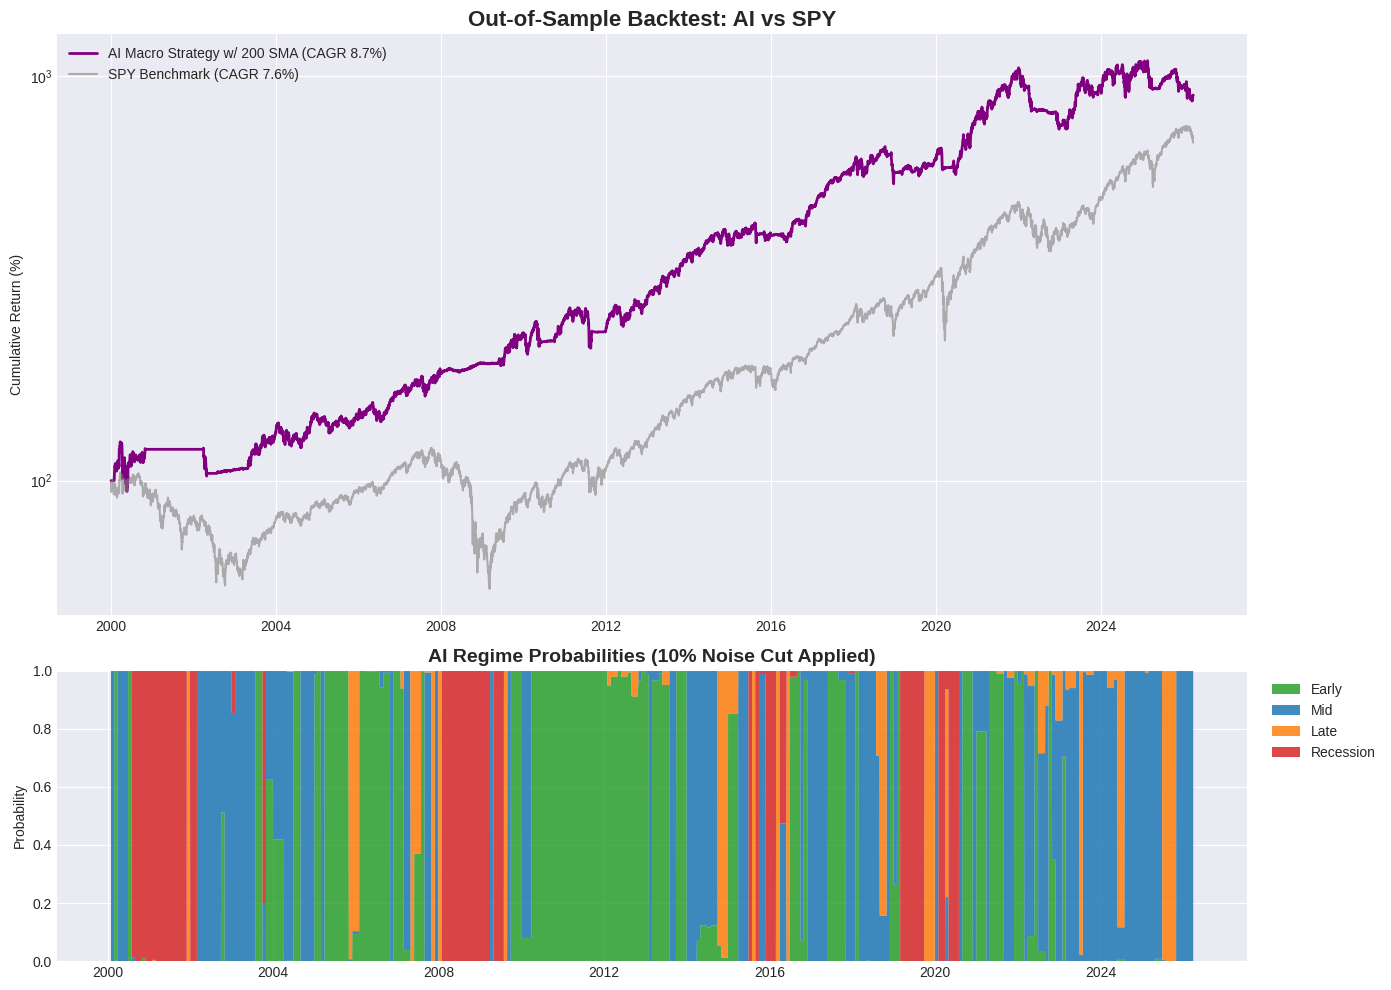

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from fredapi import Fred
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# 0. 준비: API 키 설정
# ==============================================================================
FRED_API_KEY = '2c0262037bb8a78ae5d65d9edf820cf5'
fred = Fred(api_key=FRED_API_KEY)

print("=== 🤖 1단계: 장기 매크로 데이터 로드 및 전처리 ===")
try:
    s_baa_yield = fred.get_series('BAA')   # Baa 회사채 (1919년~)
    s_10y_yield = fred.get_series('GS10')  # 10년물 국채 (1953년~)
    s_baa = s_baa_yield - s_10y_yield      # 우리가 직접 만든 신용 스프레드

    s_indpro = fred.get_series('INDPRO')
    s_tcu = fred.get_series('TCU')
    s_payems = fred.get_series('PAYEMS')
    s_t10y2y = fred.get_series('T10Y2Y')

    # 1. 일단 다 합치고 월말 기준으로 ffill만 맞춥니다. (dropna 절대 금지!)
    df_macro = pd.concat([s_indpro, s_baa, s_tcu, s_payems, s_t10y2y], axis=1)
    df_macro.columns = ['Growth', 'Credit', 'Capacity', 'Employment', 'Policy']
    df_macro = df_macro.resample('ME').last().ffill()

    # 2. 데이터가 꽉 차 있는(과거부터 있는) 상태에서 모멘텀을 계산합니다.
    df_macro['Growth_Mom'] = df_macro['Growth'].pct_change(3)
    df_macro['Credit_Mom'] = df_macro['Credit'].diff(3)
    df_macro['Capacity_Mom'] = df_macro['Capacity'].diff(3)
    df_macro['Emp_Mom'] = df_macro['Employment'].pct_change(3)
    df_macro['Policy_Mom'] = df_macro['Policy'].diff(3)

    # 3. Z-스코어 계산도 미리 해버립니다. (각 지표별로 과거 데이터가 살아있으므로 워밍업이 빠름)
    features = ['Growth_Mom', 'Credit_Mom', 'Capacity_Mom', 'Emp_Mom', 'Policy_Mom']
    df_z = (df_macro[features] - df_macro[features].rolling(60).mean()) / df_macro[features].rolling(60).std()

    # 4. 모든 계산이 끝난 후, 모델에 넣기 직전에 깔끔하게 자릅니다.
    df_z = df_z.dropna()

except Exception as e:
    print(f"🚨 FRED 서버 오류: {e}")
    raise ValueError("FRED 서버 접속 불안정. 잠시 후 다시 실행해주세요.")

# ==============================================================================
# 2. 📈 가격 데이터 로드 (장기 백테스트를 위해 2000년부터!)
# ==============================================================================
print("=== 📈 2단계: ETF 실전 투자 데이터 로드 ===")
# 💡 [추가] 횡보장/하락장 피난처용 단기 국채 ETF 'SHY' 추가
all_tickers = ['XLK', 'XLV', 'XLF', 'XLE', 'XLY', 'XLP', 'XLI', 'XLU', 'XLB', 'SPY', 'QQQ', 'SHY']
start_date = '1999-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')

etf_data = yf.download(all_tickers, start=start_date, end=end_date, progress=False)
etf_px = etf_data['Adj Close'] if 'Adj Close' in etf_data.columns.get_level_values(0) else etf_data['Close']
etf_px = etf_px.ffill().dropna(how='all') # 일부 티커 상장 전 결측치 허용

# SHY 등 상장 전 데이터는 0(현금)으로 취급하기 위해 0 채움
daily_returns = etf_px.pct_change().fillna(0.0)

# 💡 장기 테스트 시작일 조정
test_start_date = '2000-01-01'
etf_px = etf_px.loc[test_start_date:]
daily_returns = daily_returns.loc[test_start_date:]

# 💡 피델리티 오리지널 로직
cycle_playbook = {
    'Early': ['XLY', 'XLF', 'XLI', 'XLK', 'XLB'],
    'Mid': ['XLK'],
    'Late': ['XLE', 'XLP', 'XLU'],
    'Recession': ['XLY','XLP', 'XLV', 'XLU']
}

# ==============================================================================
# 3. ⚙️ 백테스트
# ==============================================================================
print("=== ⚙️ 3단계: AI 10% 미만 노이즈 제거 및 월별 타겟 비중 산출 ===")

eom_dates = etf_px.resample('ME').last().index
target_weights = pd.DataFrame(index=eom_dates, columns=etf_px.columns, data=0.0)
dynamic_probs_list = []

for date in eom_dates:
    window_size = 120

    df_train_current = df_z[df_z.index < date].tail(window_size)
    if len(df_train_current) > 60:
        gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
        gmm.fit(df_train_current)
        centroids_dynamic = gmm.means_

        # 피델리티 라벨링 로직
        growth_sorted_idx = np.argsort(centroids_dynamic[:, 0])
        idx_recession = growth_sorted_idx[0]
        idx_early = growth_sorted_idx[-1]

        rem_idx = [growth_sorted_idx[1], growth_sorted_idx[2]]
        if centroids_dynamic[rem_idx[0], 1] > centroids_dynamic[rem_idx[1], 1]:
            idx_late, idx_mid = rem_idx[0], rem_idx[1]
        else:
            idx_late, idx_mid = rem_idx[1], rem_idx[0]

        regime_map_dynamic = {
            idx_early: 'Early', idx_mid: 'Mid',
            idx_late: 'Late', idx_recession: 'Recession'
        }

        current_data = df_train_current.iloc[-1:].values
        raw_probs = gmm.predict_proba(current_data)[0]
        current_probs = {regime_map_dynamic[j]: raw_probs[j] for j in range(4)}

        prob_record = current_probs.copy()
        prob_record['Date'] = date
        dynamic_probs_list.append(prob_record)

        # 💡 [핵심] 10% 이상만 남기고 노이즈 제거
        threshold = 0.10
        filtered_probs = {regime: prob for regime, prob in current_probs.items() if prob >= threshold}

        if not filtered_probs:
            dominant_regime = max(current_probs, key=current_probs.get)
            filtered_probs = {dominant_regime: 1.0}

        # 다시 100%(1.0)로 정규화
        total_prob = sum(filtered_probs.values())
        normalized_probs = {regime: prob / total_prob for regime, prob in filtered_probs.items()}

        # 정규화된 확률로 섹터 비중 배분
        for regime, prob in normalized_probs.items():
            sectors = cycle_playbook[regime]
            weight_per_sector = prob / len(sectors)
            for s in sectors:
                target_weights.loc[date, s] += weight_per_sector
    else:
        # 데이터 부족 시 SPY 대기
        target_weights.loc[date, 'SPY'] = 1.0

df_dynamic_probs = pd.DataFrame(dynamic_probs_list).set_index('Date')

# ==============================================================================
# 3-2. ⚙️ 실전 매매 로직 적용 (+ 💡 200일선 비상 브레이크 완벽 이식)
# ==============================================================================
print("=== ⚙️ 3-2단계: 기관급 리밸런싱 및 200일선 비상 브레이크 (Absolute Momentum) 적용 ===")

# 💡 [추가] SPY 200일 이동평균선 계산
spy_200_sma = etf_px['SPY'].rolling(window=200).mean()
is_bear_market = etf_px['SPY'] < spy_200_sma # SPY가 200일선 밑으로 뚫리면 True

target_months = target_weights.index.to_period('M')
last_trading_days = daily_returns.groupby(daily_returns.index.to_period('M')).apply(lambda x: x.index[-1])

target_weights.index = target_months.map(last_trading_days)
target_weights = target_weights[target_weights.index.notna()]

# 💡 [추가] 비상 브레이크 발동! (월말 기준)
bear_market_eom = is_bear_market.reindex(target_weights.index).fillna(False)

for date in target_weights.index:
    if bear_market_eom.loc[date]: # 만약 리밸런싱 당일 시장이 200일선 아래라면?
        target_weights.loc[date] = 0.0 # AI가 짠 비중 싹 다 무시하고 0으로 리셋!
        target_weights.loc[date, 'SHY'] = 1.0 # 100% 단기채(안전마진)로 대피!

# 1. 타겟 비중을 일간 데이터 인덱스에 맞추기
target_weights_aligned = target_weights.reindex(daily_returns.index)

# 2. 월말(EOM)에 나온 신호를 다음 거래일(월초)로 하루 미룸
rebalance_signals = target_weights_aligned.shift(1)

# 3. 리밸런싱 신호가 있는 날(월초 첫 거래일)만 True로 체크
is_rebalance_day_series = ~rebalance_signals.isna().all(axis=1)

# 4. 리밸런싱 날이면서 비중 합이 0인 날(데이터 부족 기간)만 SPY 100% 할당
zero_sum_mask = is_rebalance_day_series & (rebalance_signals.sum(axis=1) == 0)
rebalance_signals.loc[zero_sum_mask, 'SPY'] = 1.0

returns_values = daily_returns.values
target_values = rebalance_signals.fillna(0.0).values # 안전장치
is_rebalance_day = is_rebalance_day_series.values

n_days = len(daily_returns)
n_assets = len(daily_returns.columns)

port_daily_ret = np.zeros(n_days)
turnover_costs = np.zeros(n_days)

current_weights = np.zeros(n_assets)
transaction_fee_rate = 0.002 # 0.2% 수수료

for i in range(n_days):
    if is_rebalance_day[i]:
        target_w = target_values[i]
        turnover = np.sum(np.abs(target_w - current_weights))
        turnover_costs[i] = turnover * transaction_fee_rate
        current_weights = target_w.copy()

    day_ret = np.sum(current_weights * returns_values[i])
    port_daily_ret[i] = day_ret - turnover_costs[i]

    if (1 + day_ret) > 0:
        current_weights = current_weights * (1 + returns_values[i]) / (1 + day_ret)
    else:
        current_weights = np.zeros(n_assets)

net_daily_return = pd.Series(port_daily_ret, index=daily_returns.index)
daily_costs = pd.Series(turnover_costs, index=daily_returns.index)

# ==============================================================================
# 4. 🚀 벤치마크 비교 성과 산출 및 최종 시각화
# ==============================================================================
print("=== 📊 4단계: 성과 지표 산출 및 시각화 (~ 현재) ===")

valid_start = '2000-01-01'

port_ret_valid = net_daily_return.loc[valid_start:]
spy_ret_valid = daily_returns.loc[valid_start:, 'SPY']

port_cum_valid = (1 + port_ret_valid).cumprod()
spy_cum_valid = (1 + spy_ret_valid).cumprod()

def calc_metrics(daily_ret, cum_ret):
    years = len(daily_ret) / 252
    cagr = (cum_ret.iloc[-1] ** (1 / years)) - 1
    mdd = (cum_ret / cum_ret.cummax() - 1).min()
    sharpe = (daily_ret.mean() / daily_ret.std()) * np.sqrt(252)
    return cagr, mdd, sharpe

ai_cagr, ai_mdd, ai_sharpe = calc_metrics(port_ret_valid, port_cum_valid)
spy_cagr, spy_mdd, spy_sharpe = calc_metrics(spy_ret_valid, spy_cum_valid)

print(f"\n🏆 성과 비교 (분석 기간: {valid_start} ~ 현재) 🏆")
print("-" * 65)
print(f"{'전략 / 벤치마크':<15} | {'CAGR (%)':<12} | {'MDD (%)':<12} | {'Sharpe Ratio':<12}")
print("-" * 65)
print(f"{'🤖 AI 모델 (+비상브레이크)':<14} | {ai_cagr*100:>8.2f} % | {ai_mdd*100:>8.2f} % | {ai_sharpe:>10.2f}")
print(f"{'📈 SPY (S&P500)':<13} | {spy_cagr*100:>8.2f} % | {spy_mdd*100:>8.2f} % | {spy_sharpe:>10.2f}")
print("-" * 65)
print(f"※ 누적 거래 수수료: {daily_costs.loc[valid_start:].sum()*100:.2f}% (정밀 차감 완료)\n")

# --- 그래프 시각화 ---
plt.style.use('seaborn-v0_8-darkgrid')
fig_backtest, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]})

# 상단: 누적 수익률 비교
ax1.plot(port_cum_valid.index, port_cum_valid * 100, label=f'AI Macro Strategy w/ 200 SMA (CAGR {ai_cagr*100:.1f}%)', color='purple', linewidth=2)
ax1.plot(spy_cum_valid.index, spy_cum_valid * 100, label=f'SPY Benchmark (CAGR {spy_cagr*100:.1f}%)', color='gray', alpha=0.6)
ax1.set_title('Out-of-Sample Backtest: AI vs SPY', fontsize=16, fontweight='bold')
ax1.set_ylabel('Cumulative Return (%)')
ax1.set_yscale('log')
ax1.legend(loc='upper left')

# 하단: 국면 확률
probs_aligned = df_dynamic_probs.reindex(port_cum_valid.index).ffill().dropna()
ax2.stackplot(probs_aligned.index,
              probs_aligned['Early'], probs_aligned['Mid'],
              probs_aligned['Late'], probs_aligned['Recession'],
              labels=['Early', 'Mid', 'Late', 'Recession'],
              colors=['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'], alpha=0.85)
ax2.set_title('AI Regime Probabilities (10% Noise Cut Applied)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Probability')
ax2.set_ylim(0, 1)
ax2.legend(loc='upper left', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.show()

=== 📊 5단계: PT용 연도별 수익률 차트 생성 ===


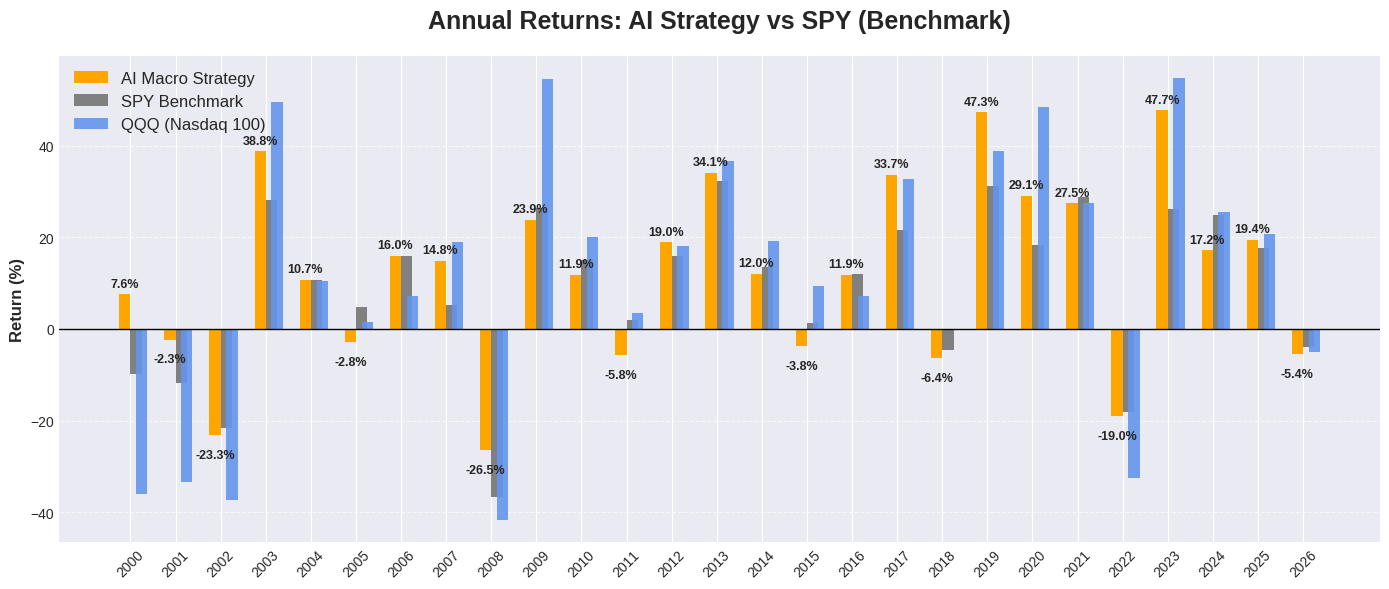

In [ ]:
# ==============================================================================
# 5. 📊 PT용 연도별 수익률 (Annual Return) 바 차트 시각화
# ==============================================================================
print("=== 📊 5단계: PT용 연도별 수익률 차트 생성 ===")
qqq_ret_valid = daily_returns.loc[valid_start:, 'QQQ']
# 1. 일일 수익률을 연도별 누적 수익률로 변환 ('YE'는 Year End)
annual_ai = (1 + port_ret_valid).resample('YE').prod() - 1
annual_spy = (1 + spy_ret_valid).resample('YE').prod() - 1
annual_qqq = (1 + qqq_ret_valid).resample('YE').prod() - 1
# 2. 인덱스를 연도(Year)로 변환
years = annual_ai.index.year
width = 0.25  # 바 두께

# 3. 그래프 그리기 세팅
fig_annual, ax_annual = plt.subplots(figsize=(14, 6))

# AI 전략은 진한 파란색, SPY는 연한 회색으로 대비
bars_ai = ax_annual.bar(years - width/2, annual_ai * 100, width, label='AI Macro Strategy', color='orange')
bars_spy = ax_annual.bar(years + width/2, annual_spy * 100, width, label='SPY Benchmark', color='gray')
bars_qqq = ax_annual.bar(years + width, annual_qqq * 100, width, label='QQQ (Nasdaq 100)', color='cornflowerblue', alpha=0.9)
# 4. 차트 꾸미기 (가독성 극대화)
ax_annual.set_title('Annual Returns: AI Strategy vs SPY (Benchmark)', fontsize=18, fontweight='bold', pad=20)
ax_annual.set_ylabel('Return (%)', fontsize=12, fontweight='bold')
ax_annual.set_xticks(years)
ax_annual.set_xticklabels(years, rotation=45)
ax_annual.axhline(0, color='black', linewidth=1) # 0% 기준선
ax_annual.legend(fontsize=12, loc='upper left')
ax_annual.grid(axis='y', linestyle='--', alpha=0.7)

# 5. 💡 [PT용 필살기] 바 위에 수익률 숫자 달아주기 (글씨가 안 겹치게 위/아래 여백 조절)
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        # 수익률이 양수면 바 위에, 음수면 바 아래에 텍스트 배치
        ypos = height + 1 if height > 0 else height - 3
        ax_annual.text(bar.get_x() + bar.get_width()/2., ypos,
                       f'{height:.1f}%',
                       ha='center', va='bottom' if height > 0 else 'top',
                       fontsize=9, fontweight='bold')

# 너무 복잡해 보이면 add_labels(bars_spy)는 주석 처리하고 AI 수익률만 보여주는 것도 좋습니다.
add_labels(bars_ai)
# add_labels(bars_spy)

plt.tight_layout()
plt.show()


=== 📅 5단계: 연도별 수익률 (Annual Returns) 산출 ===
      AI Macro (%)  SPY (%)  초과 수익률 (%p)
Date                                    
2020         29.06    18.33        10.73
2021         27.47    28.73        -1.25
2022        -19.00   -18.18        -0.82
2023         47.74    26.18        21.57
2024         17.17    24.89        -7.72
2025         19.43    17.72         1.71
2026         -5.43    -3.95        -1.48
--------------------------------------------------
=== 🥧 6단계: 투자 종목(ETF 비중) 시계열 추적 시각화 ===


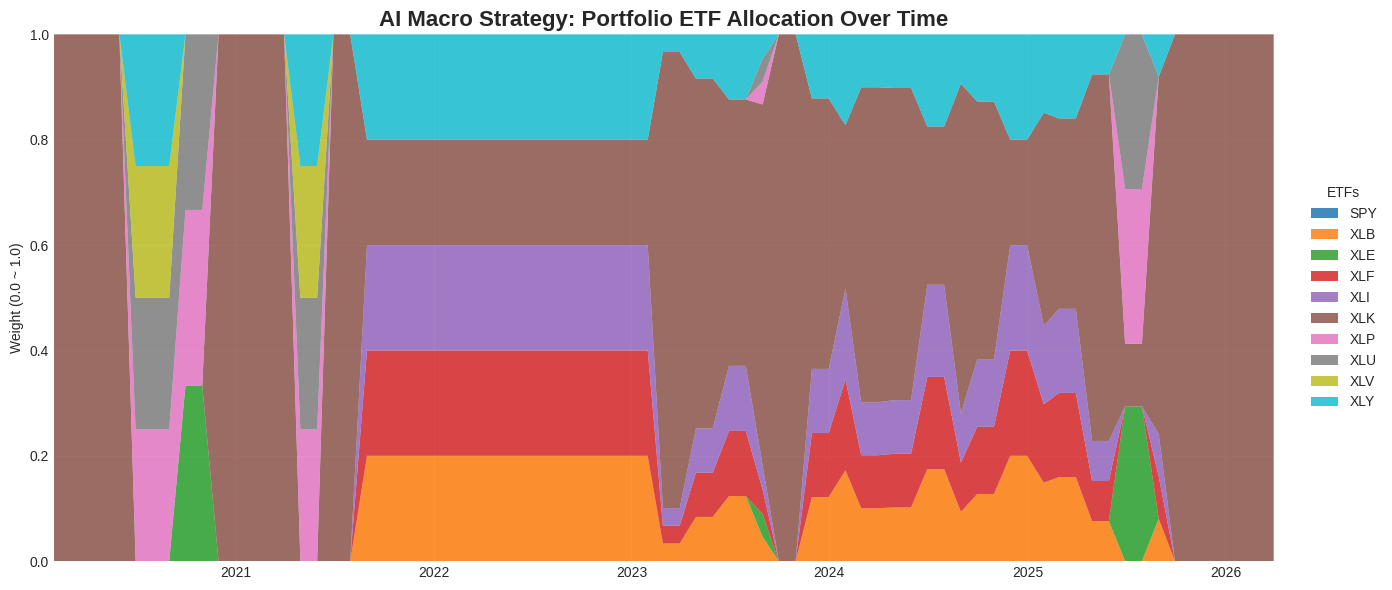


🔍 [최근 3개월 AI 포트폴리오 투자 비중 (비중 0% 제외)]
▶ 2026-01: XLK(100.0%)
▶ 2026-02: XLK(100.0%)
▶ 2026-03: XLK(100.0%)


In [ ]:
# ==============================================================================
# 5. 📅 연도별 수익률 (Annual Returns) 추출 및 콘솔 출력
# ==============================================================================
print("\n=== 📅 5단계: 연도별 수익률 (Annual Returns) 산출 ===")
validation_start = '2020-01-01'
# 인덱스의 연도(Year)를 기준으로 그룹화하여 복리 수익률 계산
annual_ai = net_daily_return.loc[validation_start:].groupby(net_daily_return.loc[validation_start:].index.year).apply(lambda x: (1+x).prod() - 1)
annual_spy = daily_returns.loc[validation_start:, 'SPY'].groupby(daily_returns.loc[validation_start:].index.year).apply(lambda x: (1+x).prod() - 1)

df_annual = pd.DataFrame({
    'AI Macro (%)': annual_ai * 100,
    'SPY (%)': annual_spy * 100
})
df_annual['초과 수익률 (%p)'] = df_annual['AI Macro (%)'] - df_annual['SPY (%)']

# 데이터프레임 소수점 포맷팅해서 깔끔하게 출력
pd.options.display.float_format = '{:.2f}'.format
print(df_annual)
print("-" * 50)

# ==============================================================================
# 6. 🥧 어떤 종목을 담았나? (포트폴리오 비중 시계열 시각화)
# ==============================================================================
print("=== 🥧 6단계: 투자 종목(ETF 비중) 시계열 추적 시각화 ===")

# 리밸런싱이 일어난 날(비중이 변한 날)의 데이터만 추출
historical_weights = rebalance_signals.loc[validation_start:].dropna(how='all').resample('ME').last().ffill()

fig_weights, ax_w = plt.subplots(figsize=(14, 6))

# 비중 누적 차트(Stackplot) 그리기
ax_w.stackplot(historical_weights.index, historical_weights.T,
               labels=historical_weights.columns, alpha=0.85, cmap='tab20')

ax_w.set_title('AI Macro Strategy: Portfolio ETF Allocation Over Time', fontsize=16, fontweight='bold')
ax_w.set_ylabel('Weight (0.0 ~ 1.0)')
ax_w.set_ylim(0, 1)
ax_w.margins(x=0)

# 범례를 차트 밖에 깔끔하게 배치
ax_w.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), title="ETFs", fontsize=10)

plt.tight_layout()
plt.show()

# 💡 최근 3개월 동안 AI가 실제로 무슨 종목을 얼마나 담았는지 콘솔에도 출력
print("\n🔍 [최근 3개월 AI 포트폴리오 투자 비중 (비중 0% 제외)]")
recent_weights = historical_weights.tail(3)
for date, row in recent_weights.iterrows():
    active_holdings = row[row > 0].sort_values(ascending=False) * 100
    holdings_str = ", ".join([f"{ticker}({weight:.1f}%)" for ticker, weight in active_holdings.items()])
    print(f"▶ {date.strftime('%Y-%m')}: {holdings_str}")

In [ ]:
# ==============================================================================
# 3-2. ⚙️ 실전 매매 로직 적용 (월 1회 리밸런싱 + 수수료 + 매매 장부 기록)
# ==============================================================================
print("=== ⚙️ 3-2단계: 기관급 리밸런싱 및 거래 장부(Trade Ledger) 생성 ===")

target_weights_aligned = target_weights.reindex(daily_returns.index)
rebalance_signals = target_weights_aligned.shift(1)
is_rebalance_day_series = ~rebalance_signals.isna().all(axis=1)

zero_sum_mask = is_rebalance_day_series & (rebalance_signals.sum(axis=1) == 0)
rebalance_signals.loc[zero_sum_mask, 'SPY'] = 1.0

returns_values = daily_returns.values
target_values = rebalance_signals.fillna(0.0).values
is_rebalance_day = is_rebalance_day_series.values
price_values = etf_px.values # 💡 매매 단가 기록을 위해 가격 데이터 추가 추출

n_days = len(daily_returns)
n_assets = len(daily_returns.columns)
etf_tickers = daily_returns.columns

port_daily_ret = np.zeros(n_days)
turnover_costs = np.zeros(n_days)
current_weights = np.zeros(n_assets)
transaction_fee_rate = 0.002 # 0.2% 수수료

# 💡 매매 내역을 담을 리스트 (장부)
trade_log = []

for i in range(n_days):
    if is_rebalance_day[i]:
        target_w = target_values[i]

# --- 📝 매매 장부(Trade Log) 기록 로직 ---
        date_obj = daily_returns.index[i]
        date_str = date_obj.strftime('%Y-%m-%d')

        # 💡 [핵심 추가] 이 리밸런싱을 촉발시킨 AI의 '국면(Regime)' 판단 가져오기
        try:
            # 가장 최근에 계산된 국면 확률 데이터를 찾아서 1등 국면을 뽑아냄
            closest_date = df_dynamic_probs.index[df_dynamic_probs.index < date_obj][-1]
            probs_row = df_dynamic_probs.loc[closest_date]
            current_regime = probs_row.idxmax() # 가장 확률이 높은 국면 이름
        except:
            current_regime = "Init / SPY"

        for j in range(n_assets):
            weight_diff = target_w[j] - current_weights[j]

            # 비중 변화가 0.1%(0.001) 이상인 유의미한 거래만 기록
            if abs(weight_diff) > 0.001:
                action = "BUY" if weight_diff > 0 else "SELL"
                price = price_values[i, j]

                trade_log.append({
                    'Date': date_str,
                    'AI Regime': current_regime,  # 💡 표의 앞단에 국면 배치!
                    'Action': action,
                    'Ticker': etf_tickers[j],
                    'Price ($)': round(price, 2),
                    'Prev Weight (%)': round(current_weights[j] * 100, 2),
                    'Target Weight (%)': round(target_w[j] * 100, 2),
                    'Trade Size (%p)': round(weight_diff * 100, 2)
                })

        # 비중 교체 및 수수료 차감
        turnover = np.sum(np.abs(target_w - current_weights))
        turnover_costs[i] = turnover * transaction_fee_rate
        current_weights = target_w.copy()

    # 오늘의 포트폴리오 수익률 계산
    day_ret = np.sum(current_weights * returns_values[i])
    port_daily_ret[i] = day_ret - turnover_costs[i]

    # 비중 자연 표류 (Weight Drift) 반영
    if (1 + day_ret) > 0:
        current_weights = current_weights * (1 + returns_values[i]) / (1 + day_ret)
    else:
        current_weights = np.zeros(n_assets)

net_daily_return = pd.Series(port_daily_ret, index=daily_returns.index)
daily_costs = pd.Series(turnover_costs, index=daily_returns.index)

# ==============================================================================
# 📝 거래 장부(Trade Ledger) CSV 파일로 저장
# ==============================================================================
df_trade_log = pd.DataFrame(trade_log)
csv_filename = 'AI_Macro_Trade_Ledger.csv'
df_trade_log.to_csv(csv_filename, index=False, encoding='utf-8-sig')

print(f"✅ 거래 내역 추출 완료! 같은 폴더에 '{csv_filename}' 파일이 생성되었습니다.")
print("📊 [최근 5건의 매매 내역 미리보기]")

=== ⚙️ 3-2단계: 기관급 리밸런싱 및 거래 장부(Trade Ledger) 생성 ===
✅ 거래 내역 추출 완료! 같은 폴더에 'AI_Macro_Trade_Ledger.csv' 파일이 생성되었습니다.
📊 [최근 5건의 매매 내역 미리보기]


=== 📊 5단계: S&P 500 & 혼재된 확률 오버레이(겹쳐 그리기) 차트 ===


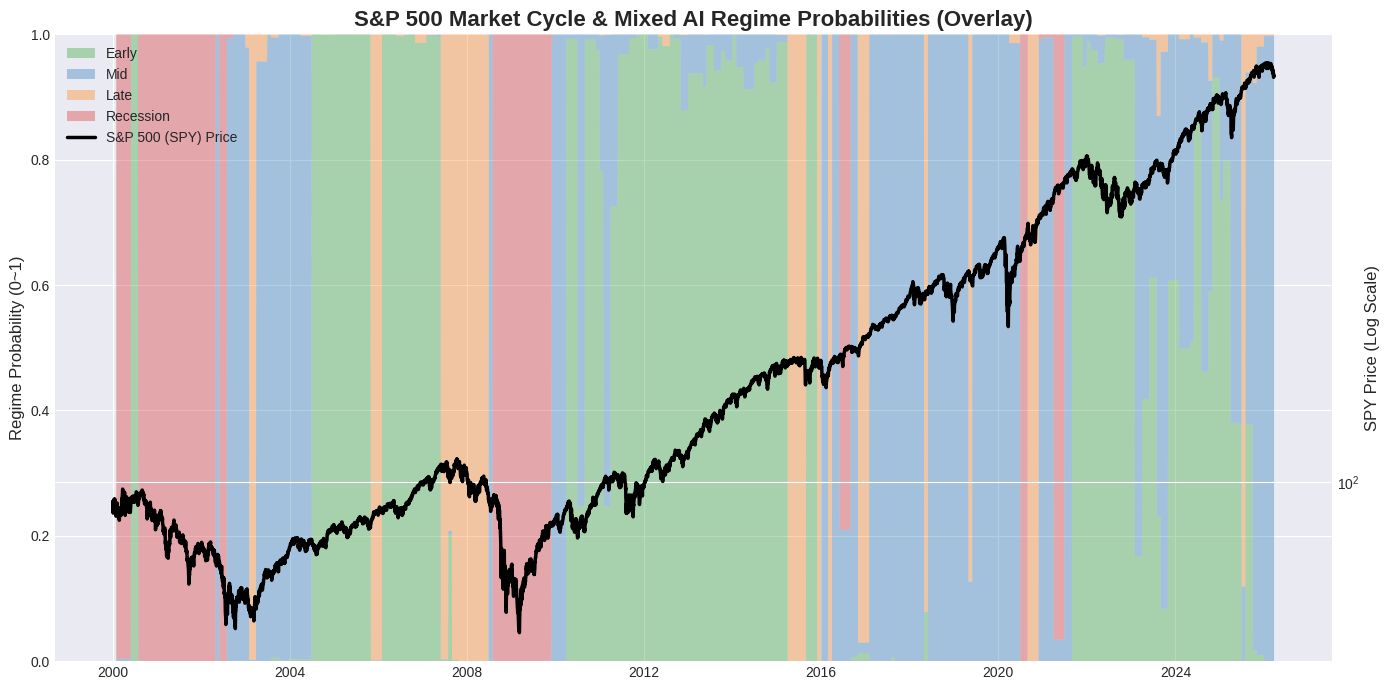

In [ ]:
print("=== 📊 5단계: S&P 500 & 혼재된 확률 오버레이(겹쳐 그리기) 차트 ===")

# SPY 가격 데이터 가져오기
spy_price_valid = etf_px.loc[valid_start:, 'SPY']

# 확률 데이터 인덱스를 SPY 가격 데이터에 맞추기
probs_aligned_chart = df_dynamic_probs.reindex(spy_price_valid.index).ffill().dropna()

fig_overlay, ax1 = plt.subplots(figsize=(14, 7))

# --- [배경] 국면 확률 100% 누적 차트 (Stackplot) ---
# ax1을 배경(확률)으로 사용합니다. 투명도(alpha=0.35)를 주어 섞인 색과 주가 선이 잘 보이게 합니다.
colors = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'] # Early, Mid, Late, Recession
ax1.stackplot(probs_aligned_chart.index,
              probs_aligned_chart['Early'], probs_aligned_chart['Mid'],
              probs_aligned_chart['Late'], probs_aligned_chart['Recession'],
              labels=['Early', 'Mid', 'Late', 'Recession'],
              colors=colors, alpha=0.35)

ax1.set_ylabel('Regime Probability (0~1)', fontsize=12)
ax1.set_ylim(0, 1)
ax1.margins(x=0) # X축 좌우 여백을 꽉 채워서 깔끔하게 만듦

# --- [전경] S&P 500 선형 차트 (로그 스케일) ---
ax2 = ax1.twinx() # 💡 핵심: X축을 공유하는 두 번째 Y축 생성
ax2.plot(spy_price_valid.index, spy_price_valid, color='black', linewidth=2.5, label='S&P 500 (SPY) Price')
ax2.set_yscale('log') # 주가는 장기 복리 왜곡 방지용 로그 스케일 적용
ax2.set_ylabel('SPY Price (Log Scale)', fontsize=12)

# 차트 타이틀 및 꾸미기
plt.title('S&P 500 Market Cycle & Mixed AI Regime Probabilities (Overlay)', fontsize=16, fontweight='bold')

# 범례 깔끔하게 합치기 (배경 확률 + 주가 선)
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', framealpha=0.9)

plt.tight_layout()
plt.show()

=== 🤖 1단계: 장기 매크로 데이터 로드 및 전처리 ===
=== 📈 2단계: ETF 실전 투자 데이터 로드 ===
=== ⚙️ 3단계: AI 10% 미만 노이즈 제거 및 월별 타겟 비중 산출 ===
=== ⚙️ 3-2단계: 기관급 리밸런싱 및 수수료/Drift 계산 ===
=== 📊 4단계: 성과 지표 산출 및 시각화 (2003년~현재) ===

🏆 성과 비교 (분석 기간: 2003-05-01 ~ 현재) 🏆
-----------------------------------------------------------------
전략 / 벤치마크       | CAGR (%)     | MDD (%)      | Sharpe Ratio
-----------------------------------------------------------------
🤖 AI 모델         |    12.69 % |   -44.00 % |       0.71
📈 SPY (S&P500) |    10.99 % |   -55.19 % |       0.65
⚖️ RSP (동일가중) |    10.91 % |   -59.92 % |       0.62
-----------------------------------------------------------------
※ 누적 거래 수수료: 15.80% (정밀 차감 완료)



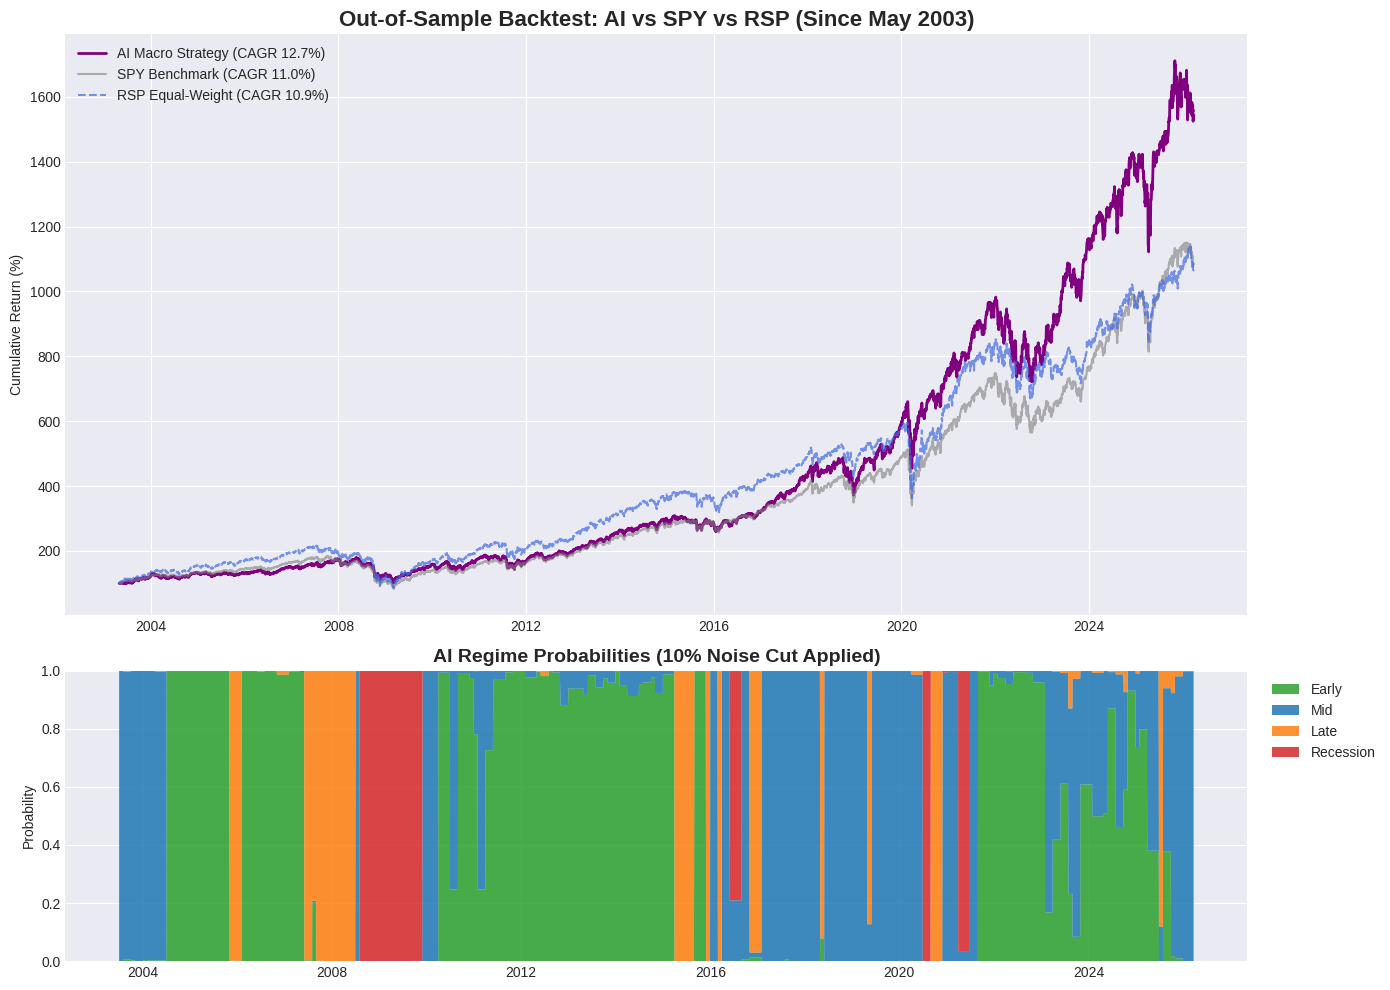

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from fredapi import Fred
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# 0. 준비: API 키 설정
# ==============================================================================
FRED_API_KEY = '2c0262037bb8a78ae5d65d9edf820cf5'
fred = Fred(api_key=FRED_API_KEY)

# ==============================================================================
# 1. 🌍 매크로 데이터 로드 및 전처리 (Expanding Window)
# ==============================================================================
print("=== 🤖 1단계: 장기 매크로 데이터 로드 및 전처리 ===")
try:
    s_indpro = fred.get_series('INDPRO')
    s_baa = fred.get_series('BAA10Y')
    s_tcu = fred.get_series('TCU')
    s_payems = fred.get_series('PAYEMS')
    s_t10y2y = fred.get_series('T10Y2Y')

    df_macro = pd.concat([s_indpro, s_baa, s_tcu, s_payems, s_t10y2y], axis=1)
    df_macro.columns = ['Growth', 'Credit', 'Capacity', 'Employment', 'Policy']
    df_macro = df_macro.resample('ME').last().ffill().dropna()

    df_macro['Growth_Mom'] = (df_macro['Growth'].pct_change(12))
    df_macro['Credit_Mom'] = df_macro['Credit'].diff(3)
    df_macro['Capacity_Mom'] = df_macro['Capacity'].diff(3)
    df_macro['Emp_Mom'] = (df_macro['Employment'].pct_change(12))
    df_macro['Policy_Mom'] = df_macro['Policy'].diff(3)

    features = ['Growth_Mom', 'Credit_Mom', 'Capacity_Mom', 'Emp_Mom', 'Policy_Mom']
    df_z = (df_macro[features] - df_macro[features].rolling(60).mean()) / df_macro[features].rolling(60).std()
    df_z = df_z.dropna()

except Exception as e:
    print(f"🚨 FRED 서버 오류: {e}")
    raise ValueError("FRED 서버 접속 불안정. 잠시 후 다시 실행해주세요.")

# ==============================================================================
# 2. 📈 가격 데이터 로드 (장기 백테스트를 위해 2000년부터!)
# ==============================================================================
print("=== 📈 2단계: ETF 실전 투자 데이터 로드 ===")
all_tickers = ['XLK', 'XLV', 'XLF', 'XLE', 'XLY', 'XLP', 'XLI', 'XLU', 'XLB', 'SPY','RSP']
start_date = '1999-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')

etf_data = yf.download(all_tickers, start=start_date, end=end_date, progress=False)
etf_px = etf_data['Adj Close'] if 'Adj Close' in etf_data.columns.get_level_values(0) else etf_data['Close']
etf_px = etf_px.ffill().dropna()

daily_returns = etf_px.pct_change().fillna(0.0)

# 💡 장기 테스트 시작일 조정
test_start_date = '2000-01-01'
etf_px = etf_px.loc[test_start_date:]
daily_returns = daily_returns.loc[test_start_date:]

# 💡 피델리티 오리지널 로직 (Late XLV 추가, Recession XLY 삭제 완료!)
cycle_playbook = {
    'Early': ['XLY', 'XLF', 'XLI', 'XLK', 'XLB'],
    'Mid': ['XLK'],
    'Late': ['XLE', 'XLP', 'XLU'],
    'Recession': ['XLY','XLP', 'XLV', 'XLU']
}

# ==============================================================================
# 3. ⚙️ 백테스트 (💡 10% 노이즈 컷 + 재정규화)
# ==============================================================================
print("=== ⚙️ 3단계: AI 10% 미만 노이즈 제거 및 월별 타겟 비중 산출 ===")

eom_dates = etf_px.resample('ME').last().index
target_weights = pd.DataFrame(index=eom_dates, columns=etf_px.columns, data=0.0)
dynamic_probs_list = []

for date in eom_dates:
    prob_date = date - pd.DateOffset(months=1)
    df_train_current = df_z.loc[:prob_date]

    if len(df_train_current) > 60:
        gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
        gmm.fit(df_train_current)
        centroids_dynamic = gmm.means_

        # 피델리티 라벨링 로직
        growth_sorted_idx = np.argsort(centroids_dynamic[:, 0])
        idx_recession = growth_sorted_idx[0]
        idx_early = growth_sorted_idx[-1]

        rem_idx = [growth_sorted_idx[1], growth_sorted_idx[2]]
        if centroids_dynamic[rem_idx[0], 1] > centroids_dynamic[rem_idx[1], 1]:
            idx_late, idx_mid = rem_idx[0], rem_idx[1]
        else:
            idx_late, idx_mid = rem_idx[1], rem_idx[0]

        regime_map_dynamic = {
            idx_early: 'Early', idx_mid: 'Mid',
            idx_late: 'Late', idx_recession: 'Recession'
        }

        current_data = df_train_current.iloc[-1:].values
        raw_probs = gmm.predict_proba(current_data)[0]
        current_probs = {regime_map_dynamic[j]: raw_probs[j] for j in range(4)}

        prob_record = current_probs.copy()
        prob_record['Date'] = date
        dynamic_probs_list.append(prob_record)

        # 💡 [핵심] 10% 이상만 남기고 노이즈 제거
        threshold = 0.10
        filtered_probs = {regime: prob for regime, prob in current_probs.items() if prob >= threshold}

        if not filtered_probs:
            dominant_regime = max(current_probs, key=current_probs.get)
            filtered_probs = {dominant_regime: 1.0}

        # 다시 100%(1.0)로 정규화
        total_prob = sum(filtered_probs.values())
        normalized_probs = {regime: prob / total_prob for regime, prob in filtered_probs.items()}

        # 정규화된 확률로 섹터 비중 배분
        for regime, prob in normalized_probs.items():
            sectors = cycle_playbook[regime]
            weight_per_sector = prob / len(sectors)
            for s in sectors:
                target_weights.loc[date, s] += weight_per_sector
    else:
        # 데이터 부족 시 SPY 대기
        target_weights.loc[date, 'SPY'] = 1.0

df_dynamic_probs = pd.DataFrame(dynamic_probs_list).set_index('Date')

# ==============================================================================
# 3-2. ⚙️ 실전 매매 로직 적용 (월 1회 리밸런싱 + 💡휴장일 증발 버그 완벽 수정)
# ==============================================================================
print("=== ⚙️ 3-2단계: 기관급 리밸런싱 및 수수료/Drift 계산 ===")

# 💡 [핵심 버그 수정] 달력 월말(주말)을 실제 주식시장의 '마지막 거래일'로 변환
target_months = target_weights.index.to_period('M')
last_trading_days = daily_returns.groupby(daily_returns.index.to_period('M')).apply(lambda x: x.index[-1])

target_weights.index = target_months.map(last_trading_days)
target_weights = target_weights[target_weights.index.notna()]

# 1. 타겟 비중을 일간 데이터 인덱스에 맞추기 (이제 주말 누락 없이 완벽 매핑됨!)
target_weights_aligned = target_weights.reindex(daily_returns.index)

# 2. 월말(EOM)에 나온 신호를 다음 거래일(월초)로 하루 미룸
rebalance_signals = target_weights_aligned.shift(1)

# 3. 리밸런싱 신호가 있는 날(월초 첫 거래일)만 True로 체크
is_rebalance_day_series = ~rebalance_signals.isna().all(axis=1)

# 4. 리밸런싱 날이면서 비중 합이 0인 날(데이터 부족 기간)만 SPY 100% 할당
zero_sum_mask = is_rebalance_day_series & (rebalance_signals.sum(axis=1) == 0)
rebalance_signals.loc[zero_sum_mask, 'SPY'] = 1.0

returns_values = daily_returns.values
target_values = rebalance_signals.fillna(0.0).values # 안전장치
is_rebalance_day = is_rebalance_day_series.values

n_days = len(daily_returns)
n_assets = len(daily_returns.columns)

port_daily_ret = np.zeros(n_days)
turnover_costs = np.zeros(n_days)

current_weights = np.zeros(n_assets)
transaction_fee_rate = 0.002 # 0.2% 수수료

for i in range(n_days):
    # 1. 리밸런싱 날 (한 달에 딱 한 번): 타겟 비중으로 교체하고 수수료 차감
    if is_rebalance_day[i]:
        target_w = target_values[i]
        turnover = np.sum(np.abs(target_w - current_weights))
        turnover_costs[i] = turnover * transaction_fee_rate
        current_weights = target_w.copy()

    # 2. 오늘의 포트폴리오 수익률 계산
    day_ret = np.sum(current_weights * returns_values[i])
    port_daily_ret[i] = day_ret - turnover_costs[i]

    # 3. 비중 자연 표류 (Weight Drift) 반영
    if (1 + day_ret) > 0:
        current_weights = current_weights * (1 + returns_values[i]) / (1 + day_ret)
    else:
        current_weights = np.zeros(n_assets)

net_daily_return = pd.Series(port_daily_ret, index=daily_returns.index)
daily_costs = pd.Series(turnover_costs, index=daily_returns.index)
# ==============================================================================
# 4. 🚀 벤치마크 비교 성과 산출 및 최종 시각화 (2003년 동시 출발)
# ==============================================================================
print("=== 📊 4단계: 성과 지표 산출 및 시각화 (2003년~현재) ===")

# 💡 RSP 상장 이후인 2003년 5월 1일로 기준점 통일
valid_start = '2003-05-01'

port_ret_valid = net_daily_return.loc[valid_start:]
spy_ret_valid = daily_returns.loc[valid_start:, 'SPY']
rsp_ret_valid = daily_returns.loc[valid_start:, 'RSP']

port_cum_valid = (1 + port_ret_valid).cumprod()
spy_cum_valid = (1 + spy_ret_valid).cumprod()
rsp_cum_valid = (1 + rsp_ret_valid).cumprod()

def calc_metrics(daily_ret, cum_ret):
    years = len(daily_ret) / 252
    cagr = (cum_ret.iloc[-1] ** (1 / years)) - 1
    mdd = (cum_ret / cum_ret.cummax() - 1).min()
    sharpe = (daily_ret.mean() / daily_ret.std()) * np.sqrt(252)
    return cagr, mdd, sharpe

ai_cagr, ai_mdd, ai_sharpe = calc_metrics(port_ret_valid, port_cum_valid)
spy_cagr, spy_mdd, spy_sharpe = calc_metrics(spy_ret_valid, spy_cum_valid)
rsp_cagr, rsp_mdd, rsp_sharpe = calc_metrics(rsp_ret_valid, rsp_cum_valid)

print(f"\n🏆 성과 비교 (분석 기간: {valid_start} ~ 현재) 🏆")
print("-" * 65)
print(f"{'전략 / 벤치마크':<15} | {'CAGR (%)':<12} | {'MDD (%)':<12} | {'Sharpe Ratio':<12}")
print("-" * 65)
print(f"{'🤖 AI 모델':<15} | {ai_cagr*100:>8.2f} % | {ai_mdd*100:>8.2f} % | {ai_sharpe:>10.2f}")
print(f"{'📈 SPY (S&P500)':<13} | {spy_cagr*100:>8.2f} % | {spy_mdd*100:>8.2f} % | {spy_sharpe:>10.2f}")
print(f"{'⚖️ RSP (동일가중)':<12} | {rsp_cagr*100:>8.2f} % | {rsp_mdd*100:>8.2f} % | {rsp_sharpe:>10.2f}")
print("-" * 65)
print(f"※ 누적 거래 수수료: {daily_costs.loc[valid_start:].sum()*100:.2f}% (정밀 차감 완료)\n")

# --- 그래프 시각화 ---
plt.style.use('seaborn-v0_8-darkgrid')
fig_backtest, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]})

# 상단: 3대장 누적 수익률 비교
ax1.plot(port_cum_valid.index, port_cum_valid * 100, label=f'AI Macro Strategy (CAGR {ai_cagr*100:.1f}%)', color='purple', linewidth=2)
ax1.plot(spy_cum_valid.index, spy_cum_valid * 100, label=f'SPY Benchmark (CAGR {spy_cagr*100:.1f}%)', color='gray', alpha=0.6)
ax1.plot(rsp_cum_valid.index, rsp_cum_valid * 100, label=f'RSP Equal-Weight (CAGR {rsp_cagr*100:.1f}%)', color='royalblue', alpha=0.7, linestyle='--')
ax1.set_title('Out-of-Sample Backtest: AI vs SPY vs RSP (Since May 2003)', fontsize=16, fontweight='bold')
ax1.set_ylabel('Cumulative Return (%)')
ax1.legend(loc='upper left')

# 하단: 국면 확률 (10% 노이즈 컷 이후)
probs_aligned = df_dynamic_probs.reindex(port_cum_valid.index).ffill().dropna()
ax2.stackplot(probs_aligned.index,
              probs_aligned['Early'], probs_aligned['Mid'],
              probs_aligned['Late'], probs_aligned['Recession'],
              labels=['Early', 'Mid', 'Late', 'Recession'],
              colors=['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'], alpha=0.85)
ax2.set_title('AI Regime Probabilities (10% Noise Cut Applied)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Probability')
ax2.set_ylim(0, 1)
ax2.legend(loc='upper left', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.show()

=== 🤖 1단계: 장기 매크로 데이터 로드 및 전처리 ===
=== 📈 2단계: ETF 실전 투자 데이터 로드 ===
=== ⚙️ 3단계: AI 10% 미만 노이즈 제거 및 월별 타겟 비중 산출 ===
=== ⚙️ 3-2단계: 기관급 리밸런싱 및 수수료/Drift 계산 ===
=== 📊 4단계: 성과 지표 산출 및 시각화 (2003년~현재) ===

🏆 성과 비교 (분석 기간: 2021-01-01 ~ 현재) 🏆
-----------------------------------------------------------------
전략 / 벤치마크       | CAGR (%)     | MDD (%)      | Sharpe Ratio
-----------------------------------------------------------------
🤖 AI 모델         |    13.79 % |   -26.60 % |       0.74
📈 SPY (S&P500) |    12.57 % |   -24.50 % |       0.78
⚖️ RSP (동일가중) |     9.79 % |   -21.38 % |       0.66
-----------------------------------------------------------------
※ 누적 거래 수수료: 3.99% (정밀 차감 완료)



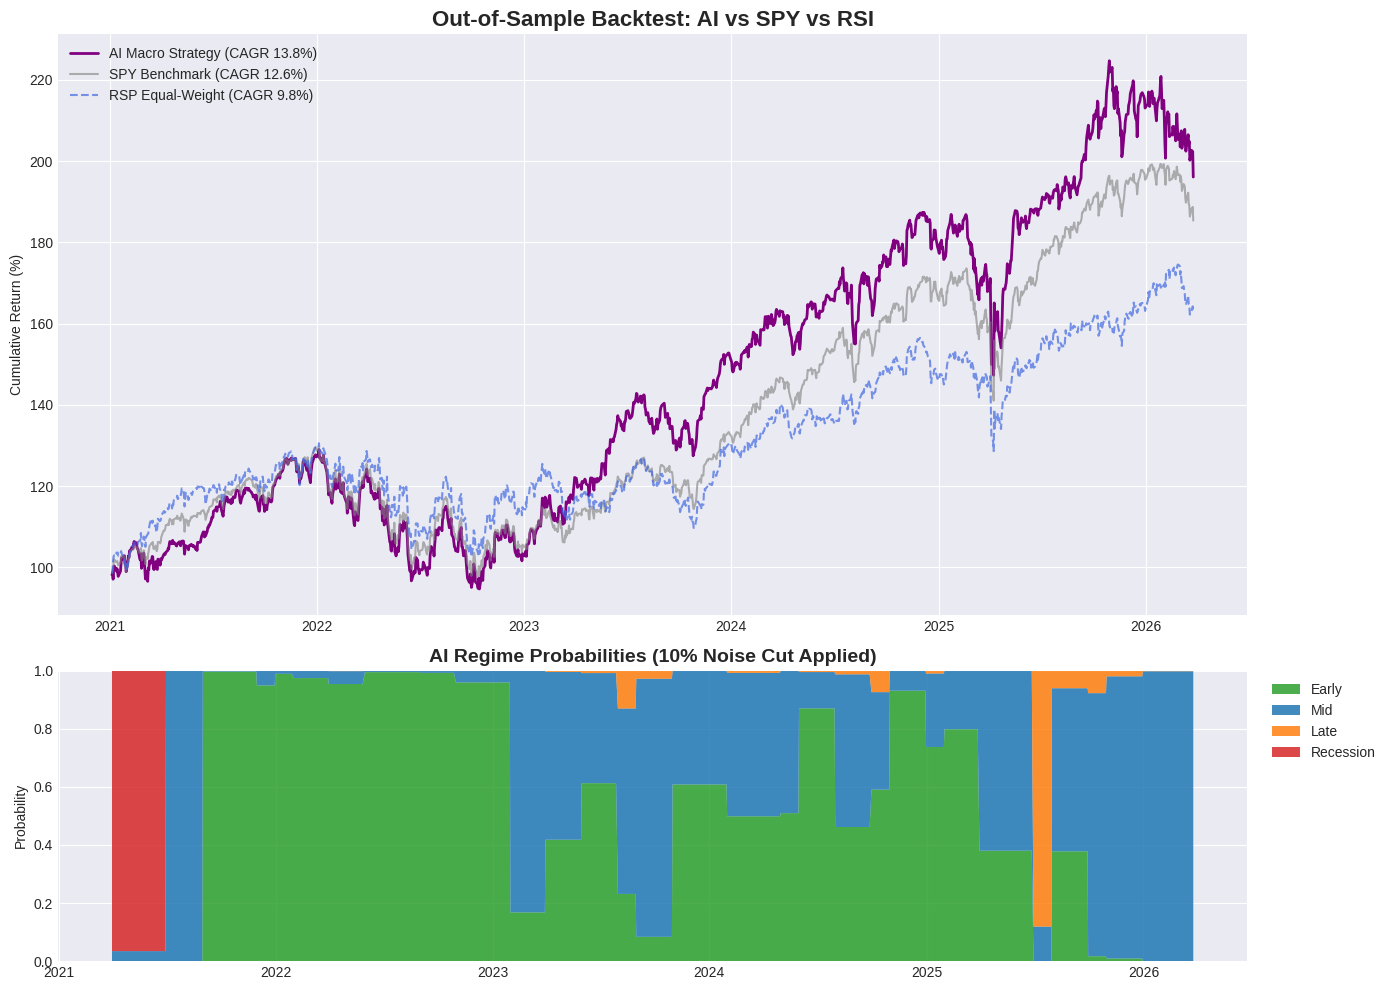

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from fredapi import Fred
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# 0. 준비: API 키 설정
# ==============================================================================
FRED_API_KEY = '2c0262037bb8a78ae5d65d9edf820cf5'
fred = Fred(api_key=FRED_API_KEY)

# ==============================================================================
# 1. 🌍 매크로 데이터 로드 및 전처리 (Expanding Window)
# ==============================================================================
print("=== 🤖 1단계: 장기 매크로 데이터 로드 및 전처리 ===")
try:
    s_indpro = fred.get_series('INDPRO')
    s_baa = fred.get_series('BAA10Y')
    s_tcu = fred.get_series('TCU')
    s_payems = fred.get_series('PAYEMS')
    s_t10y2y = fred.get_series('T10Y2Y')

    df_macro = pd.concat([s_indpro, s_baa, s_tcu, s_payems, s_t10y2y], axis=1)
    df_macro.columns = ['Growth', 'Credit', 'Capacity', 'Employment', 'Policy']
    df_macro = df_macro.resample('ME').last().ffill().dropna()

    df_macro['Growth_Mom'] = (df_macro['Growth'].pct_change(12))
    df_macro['Credit_Mom'] = df_macro['Credit'].diff(3)
    df_macro['Capacity_Mom'] = df_macro['Capacity'].diff(3)
    df_macro['Emp_Mom'] = (df_macro['Employment'].pct_change(12))
    df_macro['Policy_Mom'] = df_macro['Policy'].diff(3)

    features = ['Growth_Mom', 'Credit_Mom', 'Capacity_Mom', 'Emp_Mom', 'Policy_Mom']
    df_z = (df_macro[features] - df_macro[features].rolling(60).mean()) / df_macro[features].rolling(60).std()
    df_z = df_z.dropna()

except Exception as e:
    print(f"🚨 FRED 서버 오류: {e}")
    raise ValueError("FRED 서버 접속 불안정. 잠시 후 다시 실행해주세요.")

# ==============================================================================
# 2. 📈 가격 데이터 로드 (장기 백테스트를 위해 2000년부터!)
# ==============================================================================
print("=== 📈 2단계: ETF 실전 투자 데이터 로드 ===")
all_tickers = ['XLK', 'XLV', 'XLF', 'XLE', 'XLY', 'XLP', 'XLI', 'XLU', 'XLB', 'SPY','RSP']
start_date = '1999-01-01'
end_date = pd.Timestamp.today().strftime('%Y-%m-%d')

etf_data = yf.download(all_tickers, start=start_date, end=end_date, progress=False)
etf_px = etf_data['Adj Close'] if 'Adj Close' in etf_data.columns.get_level_values(0) else etf_data['Close']
etf_px = etf_px.ffill().dropna()

daily_returns = etf_px.pct_change().fillna(0.0)

# 💡 장기 테스트 시작일 조정
test_start_date = '2020-12-01'
etf_px = etf_px.loc[test_start_date:]
daily_returns = daily_returns.loc[test_start_date:]

# 💡 피델리티 오리지널 로직 (Late XLV 추가, Recession XLY 삭제 완료!)
cycle_playbook = {
    'Early': ['XLY', 'XLF', 'XLI', 'XLK', 'XLB'],
    'Mid': ['XLK'],
    'Late': ['XLE', 'XLP', 'XLU'],
    'Recession': ['XLY','XLP', 'XLV', 'XLU']
}

# ==============================================================================
# 3. ⚙️ 백테스트 (💡 10% 노이즈 컷 + 재정규화)
# ==============================================================================
print("=== ⚙️ 3단계: AI 10% 미만 노이즈 제거 및 월별 타겟 비중 산출 ===")

eom_dates = etf_px.resample('ME').last().index
target_weights = pd.DataFrame(index=eom_dates, columns=etf_px.columns, data=0.0)
dynamic_probs_list = []

for date in eom_dates:
    prob_date = date - pd.DateOffset(months=1)
    df_train_current = df_z.loc[:prob_date]

    if len(df_train_current) > 60:
        gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
        gmm.fit(df_train_current)
        centroids_dynamic = gmm.means_

        # 피델리티 라벨링 로직
        growth_sorted_idx = np.argsort(centroids_dynamic[:, 0])
        idx_recession = growth_sorted_idx[0]
        idx_early = growth_sorted_idx[-1]

        rem_idx = [growth_sorted_idx[1], growth_sorted_idx[2]]
        if centroids_dynamic[rem_idx[0], 1] > centroids_dynamic[rem_idx[1], 1]:
            idx_late, idx_mid = rem_idx[0], rem_idx[1]
        else:
            idx_late, idx_mid = rem_idx[1], rem_idx[0]

        regime_map_dynamic = {
            idx_early: 'Early', idx_mid: 'Mid',
            idx_late: 'Late', idx_recession: 'Recession'
        }

        current_data = df_train_current.iloc[-1:].values
        raw_probs = gmm.predict_proba(current_data)[0]
        current_probs = {regime_map_dynamic[j]: raw_probs[j] for j in range(4)}

        prob_record = current_probs.copy()
        prob_record['Date'] = date
        dynamic_probs_list.append(prob_record)

        # 💡 [핵심] 10% 이상만 남기고 노이즈 제거
        threshold = 0.10
        filtered_probs = {regime: prob for regime, prob in current_probs.items() if prob >= threshold}

        if not filtered_probs:
            dominant_regime = max(current_probs, key=current_probs.get)
            filtered_probs = {dominant_regime: 1.0}

        # 다시 100%(1.0)로 정규화
        total_prob = sum(filtered_probs.values())
        normalized_probs = {regime: prob / total_prob for regime, prob in filtered_probs.items()}

        # 정규화된 확률로 섹터 비중 배분
        for regime, prob in normalized_probs.items():
            sectors = cycle_playbook[regime]
            weight_per_sector = prob / len(sectors)
            for s in sectors:
                target_weights.loc[date, s] += weight_per_sector
    else:
        # 데이터 부족 시 SPY 대기
        target_weights.loc[date, 'SPY'] = 1.0

df_dynamic_probs = pd.DataFrame(dynamic_probs_list).set_index('Date')

# ==============================================================================
# 3-2. ⚙️ 실전 매매 로직 적용 (월 1회 리밸런싱 + 💡휴장일 증발 버그 완벽 수정)
# ==============================================================================
print("=== ⚙️ 3-2단계: 기관급 리밸런싱 및 수수료/Drift 계산 ===")

# 💡 [핵심 버그 수정] 달력 월말(주말)을 실제 주식시장의 '마지막 거래일'로 변환
target_months = target_weights.index.to_period('M')
last_trading_days = daily_returns.groupby(daily_returns.index.to_period('M')).apply(lambda x: x.index[-1])

target_weights.index = target_months.map(last_trading_days)
target_weights = target_weights[target_weights.index.notna()]

# 1. 타겟 비중을 일간 데이터 인덱스에 맞추기 (이제 주말 누락 없이 완벽 매핑됨!)
target_weights_aligned = target_weights.reindex(daily_returns.index)

# 2. 월말(EOM)에 나온 신호를 다음 거래일(월초)로 하루 미룸
rebalance_signals = target_weights_aligned.shift(1)

# 3. 리밸런싱 신호가 있는 날(월초 첫 거래일)만 True로 체크
is_rebalance_day_series = ~rebalance_signals.isna().all(axis=1)

# 4. 리밸런싱 날이면서 비중 합이 0인 날(데이터 부족 기간)만 SPY 100% 할당
zero_sum_mask = is_rebalance_day_series & (rebalance_signals.sum(axis=1) == 0)
rebalance_signals.loc[zero_sum_mask, 'SPY'] = 1.0

returns_values = daily_returns.values
target_values = rebalance_signals.fillna(0.0).values # 안전장치
is_rebalance_day = is_rebalance_day_series.values

n_days = len(daily_returns)
n_assets = len(daily_returns.columns)

port_daily_ret = np.zeros(n_days)
turnover_costs = np.zeros(n_days)

current_weights = np.zeros(n_assets)
transaction_fee_rate = 0.002 # 0.2% 수수료

for i in range(n_days):
    # 1. 리밸런싱 날 (한 달에 딱 한 번): 타겟 비중으로 교체하고 수수료 차감
    if is_rebalance_day[i]:
        target_w = target_values[i]
        turnover = np.sum(np.abs(target_w - current_weights))
        turnover_costs[i] = turnover * transaction_fee_rate
        current_weights = target_w.copy()

    # 2. 오늘의 포트폴리오 수익률 계산
    day_ret = np.sum(current_weights * returns_values[i])
    port_daily_ret[i] = day_ret - turnover_costs[i]

    # 3. 비중 자연 표류 (Weight Drift) 반영
    if (1 + day_ret) > 0:
        current_weights = current_weights * (1 + returns_values[i]) / (1 + day_ret)
    else:
        current_weights = np.zeros(n_assets)

net_daily_return = pd.Series(port_daily_ret, index=daily_returns.index)
daily_costs = pd.Series(turnover_costs, index=daily_returns.index)
# ==============================================================================
# 4. 🚀 벤치마크 비교 성과 산출 및 최종 시각화 (2003년 동시 출발)
# ==============================================================================
print("=== 📊 4단계: 성과 지표 산출 및 시각화 (2003년~현재) ===")

# 💡 RSP 상장 이후인 2003년 5월 1일로 기준점 통일
valid_start = '2021-01-01'

port_ret_valid = net_daily_return.loc[valid_start:]
spy_ret_valid = daily_returns.loc[valid_start:, 'SPY']
rsp_ret_valid = daily_returns.loc[valid_start:, 'RSP']

port_cum_valid = (1 + port_ret_valid).cumprod()
spy_cum_valid = (1 + spy_ret_valid).cumprod()
rsp_cum_valid = (1 + rsp_ret_valid).cumprod()

def calc_metrics(daily_ret, cum_ret):
    years = len(daily_ret) / 252
    cagr = (cum_ret.iloc[-1] ** (1 / years)) - 1
    mdd = (cum_ret / cum_ret.cummax() - 1).min()
    sharpe = (daily_ret.mean() / daily_ret.std()) * np.sqrt(252)
    return cagr, mdd, sharpe

ai_cagr, ai_mdd, ai_sharpe = calc_metrics(port_ret_valid, port_cum_valid)
spy_cagr, spy_mdd, spy_sharpe = calc_metrics(spy_ret_valid, spy_cum_valid)
rsp_cagr, rsp_mdd, rsp_sharpe = calc_metrics(rsp_ret_valid, rsp_cum_valid)

print(f"\n🏆 성과 비교 (분석 기간: {valid_start} ~ 현재) 🏆")
print("-" * 65)
print(f"{'전략 / 벤치마크':<15} | {'CAGR (%)':<12} | {'MDD (%)':<12} | {'Sharpe Ratio':<12}")
print("-" * 65)
print(f"{'🤖 AI 모델':<15} | {ai_cagr*100:>8.2f} % | {ai_mdd*100:>8.2f} % | {ai_sharpe:>10.2f}")
print(f"{'📈 SPY (S&P500)':<13} | {spy_cagr*100:>8.2f} % | {spy_mdd*100:>8.2f} % | {spy_sharpe:>10.2f}")
print(f"{'⚖️ RSP (동일가중)':<12} | {rsp_cagr*100:>8.2f} % | {rsp_mdd*100:>8.2f} % | {rsp_sharpe:>10.2f}")
print("-" * 65)
print(f"※ 누적 거래 수수료: {daily_costs.loc[valid_start:].sum()*100:.2f}% (정밀 차감 완료)\n")

# --- 그래프 시각화 ---
plt.style.use('seaborn-v0_8-darkgrid')
fig_backtest, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]})

# 상단: 3대장 누적 수익률 비교
ax1.plot(port_cum_valid.index, port_cum_valid * 100, label=f'AI Macro Strategy (CAGR {ai_cagr*100:.1f}%)', color='purple', linewidth=2)
ax1.plot(spy_cum_valid.index, spy_cum_valid * 100, label=f'SPY Benchmark (CAGR {spy_cagr*100:.1f}%)', color='gray', alpha=0.6)
ax1.plot(rsp_cum_valid.index, rsp_cum_valid * 100, label=f'RSP Equal-Weight (CAGR {rsp_cagr*100:.1f}%)', color='royalblue', alpha=0.7, linestyle='--')
ax1.set_title('Out-of-Sample Backtest: AI vs SPY vs RSI', fontsize=16, fontweight='bold')
ax1.set_ylabel('Cumulative Return (%)')
ax1.legend(loc='upper left')

# 하단: 국면 확률 (10% 노이즈 컷 이후)
probs_aligned = df_dynamic_probs.reindex(port_cum_valid.index).ffill().dropna()
ax2.stackplot(probs_aligned.index,
              probs_aligned['Early'], probs_aligned['Mid'],
              probs_aligned['Late'], probs_aligned['Recession'],
              labels=['Early', 'Mid', 'Late', 'Recession'],
              colors=['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'], alpha=0.85)
ax2.set_title('AI Regime Probabilities (10% Noise Cut Applied)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Probability')
ax2.set_ylim(0, 1)
ax2.legend(loc='upper left', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.show()

In [ ]:
df_z

,Growth_Mom,Credit_Mom,Capacity_Mom,Emp_Mom,Policy_Mom
1991-12-31,-0.456058,1.558740,-1.032196,-1.612765,1.421936
1992-01-31,-0.520461,-0.294778,-1.431321,-1.472116,1.272819
1992-02-29,-0.042577,-0.444391,-0.728262,-1.273472,-0.203931
1992-03-31,0.432907,-2.153967,0.359870,-1.110967,-0.198741
1992-04-30,0.599164,-0.796035,1.415181,-0.875809,-0.368153
...,...,...,...,...,...
2025-11-30,0.228589,0.097753,-0.652376,-0.641911,-0.249742
2025-12-31,-0.001650,0.383375,-0.390743,-0.779472,0.469545
2026-01-31,0.261584,-0.217047,0.766876,-0.838520,0.710347
2026-02-28,-0.032820,0.205702,0.763728,-0.991639,0.177527


In [ ]:
# ==============================================================================
# 5. 💾 실전 투자용 포트폴리오 비중 엑셀(CSV) 추출
# ==============================================================================
print("\n=== 💾 5단계: 월별 ETF 투자 비중 CSV 파일 저장 ===")

# 보기 편하도록 비중에 100을 곱해 퍼센트(%) 단위로 바꾸고, 소수점 둘째 자리까지 반올림
export_weights = (target_weights * 100).round(2)

# 인덱스(날짜) 포맷을 'YYYY-MM-DD'로 깔끔하게 정리
export_weights.index = export_weights.index.strftime('%Y-%m-%d')

# 파일명에 오늘 날짜를 넣어서 생성
today_str = pd.Timestamp.today().strftime('%Y%m%d')
file_name = f"Macro_AI_Portfolio_Weights_{today_str}.csv"

# CSV 파일로 저장 (한글 깨짐 방지를 위해 utf-8-sig 인코딩 사용)
export_weights.to_csv(file_name, encoding='utf-8-sig')

print(f"✅ 저장 완료! 현재 파이썬 코드가 있는 폴더에 '{file_name}' 파일이 생성되었습니다.")

# 보너스: 콘솔 창에서도 가장 최근(이번 달) 비중을 바로 확인할 수 있게 출력
latest_date = export_weights.index[-1]
latest_weights = export_weights.iloc[-1]
active_positions = latest_weights[latest_weights > 0] # 비중이 0%인 건 빼고 출력

print(f"\n🔔 [가장 최근 리밸런싱 지시서: {latest_date} 기준]")
print("-" * 40)
for ticker, weight in active_positions.items():
    print(f"💰 {ticker:<4} : {weight:>6}%")
print("-" * 40)


=== 💾 5단계: 월별 ETF 투자 비중 CSV 파일 저장 ===


NameError: name 'target_weights' is not defined

In [ ]:
# 1. 코랩 리눅스 서버에 나눔고딕 폰트 조용히 설치
!apt-get -qq -y install fonts-nanum > /dev/null

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 2. 파이썬 폰트 매니저에게 방금 깐 폰트 위치를 강제로 주입 (핵심!)
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)

# 3. 도화지(matplotlib) 기본 폰트를 나눔고딕으로 설정
plt.rc('font', family='NanumGothic')

# 4. 마이너스(-) 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

print("✅ 코랩 한글 폰트 강제 패치 완료! 이제 3D 그래프를 다시 그려보세요.")

✅ 코랩 한글 폰트 강제 패치 완료! 이제 3D 그래프를 다시 그려보세요.



=== 📊 6단계: 3D GMM 클러스터링 시각화 생성 중 ===


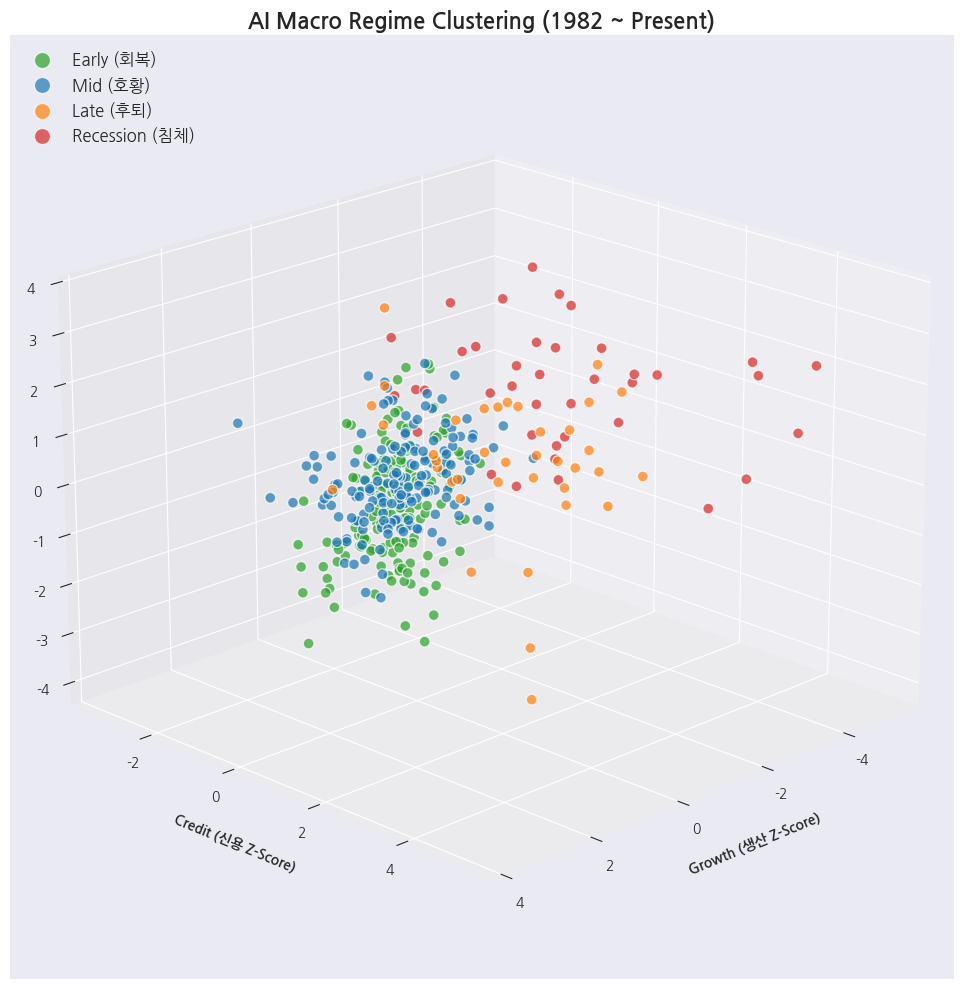

In [ ]:
# ==============================================================================
# 6. 📊 프레젠테이션용 3D GMM 국면 시각화 (Scatter Plot)
# ==============================================================================

# ==========================================
print("\n=== 📊 6단계: 3D GMM 클러스터링 시각화 생성 중 ===")
from mpl_toolkits.mplot3d import Axes3D

# 전체 데이터를 기준으로 GMM 최종 학습 및 라벨링 (시각화용)
gmm_viz = GaussianMixture(n_components=4, covariance_type='full', random_state=42)
gmm_labels = gmm_viz.fit_predict(df_z[features])
centroids_viz = gmm_viz.means_

# 국면 이름표 달기 (기존 라벨링 로직과 동일)
growth_sorted_idx = np.argsort(centroids_viz[:, 0])
idx_recession = growth_sorted_idx[0]
idx_early = growth_sorted_idx[-1]

rem_idx = [growth_sorted_idx[1], growth_sorted_idx[2]]
if centroids_viz[rem_idx[0], 1] > centroids_viz[rem_idx[1], 1]:
    idx_late, idx_mid = rem_idx[0], rem_idx[1]
else:
    idx_late, idx_mid = rem_idx[1], rem_idx[0]

regime_map_viz = {
    idx_early: 'Early (회복)',
    idx_mid: 'Mid (호황)',
    idx_late: 'Late (후퇴)',
    idx_recession: 'Recession (침체)'
}

# 시각화를 위해 df_z 복사본에 국면(Regime) 컬럼 추가
df_viz = df_z.copy()
df_viz['Regime'] = [regime_map_viz[label] for label in gmm_labels]

# 🎨 3D 그래프 그리기 세팅
fig_3d = plt.figure(figsize=(14, 10))
ax_3d = fig_3d.add_subplot(111, projection='3d')

# 국면별 고유 색상 지정
color_map = {
    'Early (회복)': '#2ca02c',     # 초록색
    'Mid (호황)': '#1f77b4',       # 파란색
    'Late (후퇴)': '#ff7f0e',      # 주황색
    'Recession (침체)': '#d62728'  # 빨간색
}

# 각 국면별로 점 찍기
for regime, color in color_map.items():
    subset = df_viz[df_viz['Regime'] == regime]
    ax_3d.scatter(
        subset['Growth_Mom'],   # X축: 성장 (생산)
        subset['Credit_Mom'],   # Y축: 신용 (회사채 스프레드)
        subset['Policy_Mom'],   # Z축: 정책 (장단기 금리차)
        c=color,
        label=regime,
        alpha=0.7,
        edgecolors='w',
        s=60
    )

# 축 이름 및 타이틀 설정
ax_3d.set_xlabel('Growth (생산 Z-Score)', fontweight='bold', labelpad=10)
ax_3d.set_ylabel('Credit (신용 Z-Score)', fontweight='bold', labelpad=10)
ax_3d.set_zlabel('Policy (금리 Z-Score)', fontweight='bold', labelpad=10)
ax_3d.set_title('AI Macro Regime Clustering (1982 ~ Present)', fontsize=16, fontweight='bold')

# 범례 표시 및 각도 조절
ax_3d.legend(loc='upper left', fontsize=12, markerscale=1.5)
ax_3d.view_init(elev=20, azim=45) # 발표 자료에 예쁘게 보이도록 카메라 각도 조절

plt.tight_layout()
plt.show()